## **Business Understanding**
### **Background**

The stock market plays a crucial role in economic development by enabling companies to raise capital and providing investors with opportunities to grow their wealth. In Kenya, the Nairobi Securities Exchange serves as the primary platform where publicly listed companies trade their shares.

Investors often rely on historical price trends, financial analysis, and market news when making investment decisions. However, predicting stock price movements remains a complex task due to market volatility, investor behavior, and external economic influences.

One of the most actively traded companies on the exchange is Safaricom. Due to its large market capitalization and high trading volume, Safaricom plays a significant role in influencing overall market activity. Analyzing and forecasting its stock price movements can therefore provide useful insights into investment strategies and market dynamics.

With the availability of historical market data and advancements in machine learning techniques, it is now possible to build predictive models that can identify patterns in stock price movements. These models can assist investors and analysts in making more informed decisions by estimating future price trends based on historical data.

### **Market Research**

This section explains:

- how the Nairobi Securities Exchange works
- importance of stock prediction
- importance of Safaricom in the market
- existing prediction methods

The `Nairobi Securities Exchange`(NSE) is the primary securities exchange in Kenya where publicly listed companies trade shares and other financial instruments. The exchange plays a significant role in facilitating investment, capital formation, and economic growth within the country.

Stock prices in financial markets are influenced by a variety of factors including company performance, macroeconomic conditions, investor sentiment, and trading activity. As a result, forecasting stock price movements has become an important area of research in finance and data science.

Among the companies listed on the exchange, `Safaricom` is one of the most actively traded stocks. Due to its large market capitalization and high liquidity, Safaricom frequently accounts for a significant portion of total trading activity in the market. This makes it an important case study for analyzing stock price behavior in the Kenyan market.

In recent years, machine learning and data-driven approaches have been increasingly applied to financial forecasting. Techniques such as regression models, tree-based algorithms, and neural networks have shown potential in identifying hidden patterns within historical financial data. These methods can complement traditional financial analysis by providing predictive insights based on historical trading patterns.

By leveraging historical trading data from the Nairobi Securities Exchange, this project explores how machine learning techniques can be applied to predict stock prices and identify potential investment opportunities within the Kenyan market.

### **Problem Statement**

Predicting stock price movements remains a significant challenge due to the dynamic and unpredictable nature of financial markets. Investors in the Nairobi Securities Exchange often rely on historical price trends and manual analysis when making investment decisions, which may not always capture hidden patterns within large datasets.

Despite the availability of historical trading data, there is limited use of data-driven predictive models specifically focused on stocks listed in the Kenyan market. This creates an opportunity to explore how machine learning techniques can be used to analyze historical stock data and generate reliable price forecasts.

This project seeks to develop a predictive model capable of estimating the next-day closing price of Safaricom using historical trading data. Additionally, the study will extend the analysis to a broader market perspective by applying the model to multiple stocks listed on the Nairobi Securities Exchange in order to identify the top 20 stocks with the highest predicted returns.

### **Objectives**
#### *Main Objective*
To develop a machine learning model that predicts future stock prices using historical trading data from the Nairobi Securities Exchange.

#### *Specific Objectives*
1. To analyze historical trading data of Safaricom stock from 2007 to 2025.
2. To perform exploratory data analysis in order to understand price trends, volatility, and trading patterns..
3. To train and evaluate multiple machine learning models for predicting next-day stock prices.
4. To extend the prediction model to multiple stocks listed on the Nairobi Securities Exchange.
5. To rank stocks based on predicted returns and identify the top 20 potentially high-performing stocks.

### **Stakeholders**

Several stakeholders may benefit from insights generated in this project:
1. Investors and Traders - Individual and institutional investors can use predictive insights to support investment decision-making and identify potential opportunities within the stock market.

2. Financial Analysts - Market analysts can utilize predictive models to complement traditional financial analysis methods when evaluating stock performance.

3. tock Brokerage Firms - Brokerage firms may use predictive insights to provide data-driven recommendations to their clients.

4. Researchers and Data Scientists - This project contributes to the growing field of financial data science by demonstrating how machine learning techniques can be applied to stock market prediction using local market data.

5. The Nairobi Securities Exchange - Insights derived from this analysis may contribute to a deeper understanding of trading patterns and market dynamics within the exchange.

## **Data Understanding**
### **Data Sources**
The dataset used in this project consists of historical stock market trading data from the Nairobi Securities Exchange covering the period `2007` to `OCT 2025`. The data contains daily trading records for multiple companies listed on the exchange.

Each record includes information such as the trading date, stock code, company name, daily price movements, trading volume, and other related indicators.

The dataset was collected in multiple files organized by year. To facilitate analysis, the files are combined into a single dataset that contains all trading records within the study period.

*importing the required libraries and loading the data* 

In [1]:
# Load relevant libraries.
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Define the data path
DATA_PATH = Path("../data/raw_data")

print(DATA_PATH)

..\data\raw_data


First, we load a sample file to inspect the data. 

In [3]:
# Load the 2007 data into a variable
df_2007 = pd.read_csv(DATA_PATH / "NSE_data_all_stocks_2007.csv")

# Inspect the first 5 rows
df_2007.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


- From this sample, we already note inconsistencies, especially in the column names; there are some that are in uppercase, whereas some are in title case.

- Also, in some columns, we can see that a dash (-) is used, we'll find out why later.

In [4]:
# Inspect the datasets details (nulls, number of columns etc.)
df_2007.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DATE       10608 non-null  str  
 1   CODE       10608 non-null  str  
 2   NAME       10585 non-null  str  
 3   12m Low    10608 non-null  str  
 4   12m High   10608 non-null  str  
 5   Day Low    10608 non-null  str  
 6   Day High   10608 non-null  str  
 7   Day Price  10608 non-null  str  
 8   Previous   10608 non-null  str  
 9   Change     10608 non-null  str  
 10  Change%    10608 non-null  str  
 11  Volume     10608 non-null  str  
 12  Adjust     10608 non-null  str  
dtypes: str(13)
memory usage: 1.1 MB


From the summary above, the dataset;
- contains missing data in only one column
- all data is stored as objects
- has 13 columns

In [5]:
# Print columns
df_2007.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust'],
      dtype='str')

#### *Combine All Datasets*
As mentioned ealier, we are combining the datasets under one variable for easy access 

In [6]:
# Find all files in the raw_data folder
files = glob.glob("../data/raw_data/*.csv")

# Ensure all files are found
files

['../data/raw_data\\NSE_data_all_stocks_2007-2025.csv',
 '../data/raw_data\\NSE_data_all_stocks_2007.csv',
 '../data/raw_data\\NSE_data_all_stocks_2008.csv',
 '../data/raw_data\\NSE_data_all_stocks_2009.csv',
 '../data/raw_data\\NSE_data_all_stocks_2010.csv',
 '../data/raw_data\\NSE_data_all_stocks_2011.csv',
 '../data/raw_data\\NSE_data_all_stocks_2012.csv',
 '../data/raw_data\\NSE_data_all_stocks_2013.csv',
 '../data/raw_data\\NSE_data_all_stocks_2014.csv',
 '../data/raw_data\\NSE_data_all_stocks_2015.csv',
 '../data/raw_data\\NSE_data_all_stocks_2016.csv',
 '../data/raw_data\\NSE_data_all_stocks_2017.csv',
 '../data/raw_data\\NSE_data_all_stocks_2018.csv',
 '../data/raw_data\\NSE_data_all_stocks_2019.csv',
 '../data/raw_data\\NSE_data_all_stocks_2020.csv',
 '../data/raw_data\\NSE_data_all_stocks_2021.csv',
 '../data/raw_data\\NSE_data_all_stocks_2021_upto_31dec2021.csv',
 '../data/raw_data\\NSE_data_all_stocks_2022.csv',
 '../data/raw_data\\NSE_data_all_stocks_2023.csv',
 '../data/r

In [7]:
# Create an empty list
dfs = []

# Loop over every file and read the contents
for file in files:
    df = pd.read_csv(file)

    # Append the dataframes to the empty list, dfs, to create a list of dataframes with no index
    dfs.append(df)

C:\Users\User\AppData\Local\Temp\ipykernel_26220\4220449471.py:6: DtypeWarning: Columns (0: DATE, 1: CODE, 2: NAME, 3: Adjust, 4: Date, 5: Adjusted, 6: Code, 7: Name, 8: Adjusted Price) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


In [8]:
# Concatenate the dataframes to create one dataframe
combined_df = pd.concat(dfs, ignore_index=True)

# Review the first 15 rows
combined_df.head(15)

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,DATE,CODE,NAME,12m Low,12m High,Day Low,...,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
0,0.0,0.0,0.0,0.0,1/2/2007,EGAD,Eaagads,22,57,52,...,52,-,-,300,26,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1/2/2007,KAPC,Kapchorua Tea,111,148,100,...,98.5,1.5,1.50%,"7,800",-,NaN,NaN,NaN,NaN,NaN
2,2.0,2.0,2.0,2.0,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,...,42.25,1.25,2.87%,"2,700",-,NaN,NaN,NaN,NaN,NaN
3,3.0,3.0,3.0,3.0,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,...,25.75,-0.25,0.98%,"10,500",-,NaN,NaN,NaN,NaN,NaN
4,4.0,4.0,4.0,4.0,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,...,141,-1,0.71%,"70,900",23.33,NaN,NaN,NaN,NaN,NaN
5,5.0,5.0,5.0,5.0,1/2/2007,UTK,Unilever Tea Kenya,45,45,80,...,81.5,-0.5,0.62%,"1,000",-,NaN,NaN,NaN,NaN,NaN
6,6.0,6.0,6.0,6.0,1/2/2007,WTK,Williamson Tea Kenya,180,290,120,...,118,2,1.67%,"10,000",-,NaN,NaN,NaN,NaN,NaN
7,7.0,7.0,7.0,7.0,1/2/2007,C&G,Car and General (K),21,29,50,...,50,-,-,"66,700",33.33,NaN,NaN,NaN,NaN,NaN
8,8.0,8.0,8.0,8.0,1/2/2007,CMC,CMC Holdings,13.5,13.5,173,...,173,15,7.98%,"36,200",15.67,NaN,NaN,NaN,NaN,NaN
9,9.0,9.0,9.0,9.0,1/2/2007,FIRE,Sameer Africa,3.4,5.95,22.5,...,24,0.75,3.03%,"54,800",-,NaN,NaN,NaN,NaN,NaN


In [9]:
# Review the last 15 rows
combined_df.tail(15)

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,DATE,CODE,NAME,12m Low,12m High,Day Low,...,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
1537870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.27,0.27,0.27,...,0.27,-,-,-,NaN,31-Oct-25,NaN,MSC,Mumias Sugar Company Ltd,-
1537871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.8,9.0,7.28,...,8.06,-0.6,-7.44%,6820,NaN,31-Oct-25,NaN,SKL,Shri Krishana Overseas Plc,-
1537872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.4,28.25,24.5,...,24.7,-0.05,-0.20%,1569,NaN,31-Oct-25,NaN,UNGA,Unga Group Ltd,-
1537873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.1,31.0,29.6,...,29.55,0.7,2.37%,3051822,NaN,31-Oct-25,NaN,SCOM,Safaricom Plc,-
1537874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0,20.0,...,20,-,-,-,NaN,31-Oct-25,NaN,LAPR,Laptrust Imara Income-REIT,-
1537875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,9800.0,4840.0,...,4835,75,1.55%,539,NaN,31-Oct-25,NaN,GLD,ABSA NewGold ETF,-
1537876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755.0,1000.0,854.0,...,857,-2,-0.23%,27,NaN,31-Oct-25,NaN,SMWF,Satrix MSCI World Feeder ETF,-
1537877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1170.1,1934.23,1910.77,...,1877.52,33.25,1.77%,-,NaN,31-Oct-25,NaN,^N10I,NSE 10-Share Index,-
1537878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1823.17,3153.39,3116.69,...,3090.7,25.99,0.84%,-,NaN,31-Oct-25,NaN,^N20I,NSE 20-Share Index,-
1537879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3063.32,5052.98,4998.39,...,4900.89,97.5,1.99%,-,NaN,31-Oct-25,NaN,^N25I,NSE 25-Share Index,-


In [10]:
# Turn it into a CSV file
combined_df.to_csv("../data/raw_data/processed/NSE_data_all_stocks_2007-2025.csv", index=False)

### **Data Description**
Here, we will be examining the data structure, such as record counts and field types (numerical, categorical, text).

#### *Shape*

In [11]:
# Shape of the dataset
print("Rows, Columns:", combined_df.shape)

Rows, Columns: (1537885, 22)


#### *Columns*

In [12]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='str')

#### *Data Summary*

In [13]:
# Data types and non-null values
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537885 entries, 0 to 1537884
Data columns (total 22 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Unnamed: 0.3    1204020 non-null  float64
 1   Unnamed: 0.2    903015 non-null   float64
 2   Unnamed: 0.1    602010 non-null   float64
 3   Unnamed: 0      301005 non-null   float64
 4   DATE            1133281 non-null  str    
 5   CODE            1186196 non-null  str    
 6   NAME            1185956 non-null  str    
 7   12m Low         1537875 non-null  object 
 8   12m High        1537875 non-null  object 
 9   Day Low         1537875 non-null  object 
 10  Day High        1537875 non-null  object 
 11  Day Price       1537875 non-null  object 
 12  Previous        1537875 non-null  str    
 13  Change          1537875 non-null  str    
 14  Change%         1537875 non-null  str    
 15  Volume          1537875 non-null  str    
 16  Adjust          1133281 non-null  str    
 17  

From the summary above, we note a lot of differences from our sample data;
- Instead of 13 columns, we have 22.
- We now have 3 data types; float, object and string.
- There are different columns that have the same name but written differently.
- Also, only 9 out of the 22 columns seem complete, an issue that might have been brought about by the inconsistent naming of columns.

#### *Statistical Inspection*

In [14]:
# Summary stats for numerical columns
combined_df.describe()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
count,1.204020e+06,903015.000000,602010.000000,301005.000000
mean,6.020095e+05,451507.000000,301004.500000,150502.000000
std,3.475708e+05,260678.121004,173785.462115,86892.803226
min,0.000000e+00,0.000000,0.000000,0.000000
25%,3.010048e+05,225753.500000,150502.250000,75251.000000
50%,6.020095e+05,451507.000000,301004.500000,150502.000000
75%,9.030142e+05,677260.500000,451506.750000,225753.000000
max,1.204019e+06,903014.000000,602009.000000,301004.000000


In [15]:
# Check unique values for each column (useful for categorical vars)
combined_df.nunique()

Unnamed: 0.3      1204020
Unnamed: 0.2       903015
Unnamed: 0.1       602010
Unnamed: 0         301005
DATE                 3491
CODE                   99
NAME                  143
12m Low               991
12m High             1132
Day Low             24923
Day High            24910
Day Price           25760
Previous            21596
Change               5960
Change%              2353
Volume              31270
Adjust               3905
Date                 1195
Adjusted             1063
Code                   79
Name                   81
Adjusted Price         45
dtype: int64

### **Data Quality Assessment** 
We wiil be identifying missing values, outliers, noise, and potential biases that might affect modeling in the future.

#### *Missing values*

In [16]:
# Total and percent missing
missing = combined_df.isnull().sum()
missing_percent = (missing / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
Unnamed: 0.3,333865,21.709361
Unnamed: 0.2,634870,41.282020
Unnamed: 0.1,935875,60.854680
Unnamed: 0,1236880,80.427340
DATE,404604,26.309119
CODE,351689,22.868355
NAME,351929,22.883961
12m Low,10,0.000650
12m High,10,0.000650
Day Low,10,0.000650


- As mentioned earlier, the merged dataset contains a lot of missing values, probably brough about by the different naming conventions used in the different datasets merged.

#### *Duplicates*

In [17]:
# Check duplicates
combined_df.duplicated().sum()

np.int64(32949)

- The dataset contains 89 duplicate records

#### *Data Integrity Issues*
According to [a Gartner Survey](https://www.gartner.com/en/insights), data issues, including inaccuracies, incompleteness, duplication, and inconsistency, severely hinder business insights, causing an estimated $12.9 million in annual losses.

In our merged dataset, we have identified the following issues.

|No. | Issue |
| ------ | ------- |
| 1. | Inconsistent column names |
| 2. | Missing values |
| 3. | Duplicates |
| 4. | Wrong data formats |

## **Data Cleaning**

Data cleaning is a critical step in the data science workflow that involves identifying and correcting errors, inconsistencies, and inaccuracies in a dataset. Raw data collected from different sources or across long time periods often contains issues such as missing values, inconsistent column naming, duplicate variables, incorrect data formats, and redundant information. If these issues are not addressed, they can negatively affect the quality of analysis and the performance of predictive models.

In the context of this project, the Nairobi Securities Exchange (NSE) dataset was compiled from multiple yearly records spanning from 2007 to 2025. Because the data originates from different time periods and potentially different reporting formats, several inconsistencies were observed during the data understanding phase. These include variations in column naming conventions (for example, `DATE` vs `Date`), duplicate columns representing the same variable, automatically generated index columns, and missing values resulting from the merging process.

The objective of the data cleaning stage is therefore to transform the raw merged dataset into a structured and consistent format suitable for analysis and modeling. The key steps performed in this phase include:

- Resolving inconsistencies in column names.
- Merging duplicate columns representing the same variables.
- Removing redundant or unnecessary columns.
- Standardizing the structure and ordering of dataset columns.
- Preparing the dataset for further preprocessing steps such as data type conversion and exploratory data analysis.

By completing these cleaning steps, the dataset becomes more reliable and suitable for downstream tasks including exploratory analysis, feature engineering, and the development of machine learning models for stock price prediction.

### **Handling Column Name Inconsistencies**

After merging the NSE datasets from multiple years, several duplicated columns were identified. These duplicates occurred because different datasets used different capitalization styles for the same variables.

Examples include:

| Column Version 1 | Column Version 2 |
|------------------|------------------|
| DATE | Date |
| CODE | Code |
| NAME | Name |
| Adjust | Adjusted |
| Adjusted Price | Adjust |

Because pandas treats column names as case-sensitive, these columns were interpreted as separate variables during the merge process. As a result, some rows contain values in one column while the corresponding duplicate column contains missing values.

#### **Cleaning Strategy**

To resolve this issue:
1. Merge duplicated columns representing the same variable.
2. Fill missing values in one column using values from the other column.
3. Retain a single standardized column name.
4. Remove redundant columns after merging.

This ensures the dataset maintains a consistent schema across all observations.

In [18]:
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='str')

##### *`date`*

In [19]:
# combine Date and DATE columns into one column called date
combined_df['date'] = combined_df['DATE'].fillna(combined_df['Date'])

In [20]:
# check the new date column for nulls
combined_df['date'].isna().sum()

np.int64(10)

##### *`code`*

In [21]:
# combine Code and CODE columds
combined_df['code'] = combined_df['CODE'].fillna(combined_df['Code'])

In [22]:
#Check the code colums for nulls
combined_df['code'].isna().sum()

np.int64(10)

##### *`name`*

In [23]:
# combine name and NAME columns
combined_df['name'] = combined_df['NAME'].fillna(combined_df['Name'])

In [24]:
# check the name column for nulls
combined_df['name'].isna().sum()

np.int64(250)

##### *`adjusted_price`*

In [25]:
# combine Adjusted Price, Adjust and Adjusted columns into one column called adjusted_price
combined_df['adjusted_price'] = combined_df['Adjusted Price'].fillna(combined_df['Adjust'])
combined_df['adjusted_price'] = combined_df['adjusted_price'].fillna(combined_df['Adjusted'])

In [26]:
# check the adjusted_prices column for nulls
combined_df['adjusted_price'].isna().sum()

np.int64(10)

In [27]:
# Confirm if all added columns are there.
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'DATE',
       'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price', 'date', 'code',
       'name', 'adjusted_price'],
      dtype='str')

In [28]:
# drop the original columns that have been combined into new columns
combined_df = combined_df.drop(columns=[
'DATE','Date',
'CODE','Code',
'NAME','Name',
'Adjust','Adjusted','Adjusted Price'
])

In [29]:
# Confirm if all column issues are sorted.
combined_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', '12m Low',
       '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change',
       'Change%', 'Volume', 'date', 'code', 'name', 'adjusted_price'],
      dtype='str')

In [30]:
# Review the changes.
combined_df.head()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,date,code,name,adjusted_price
0,0.0,0.0,0.0,0.0,22,57,52,52,52,52,-,-,300,1/2/2007,EGAD,Eaagads,26
1,1.0,1.0,1.0,1.0,111,148,100,100,100,98.5,1.5,1.50%,"7,800",1/2/2007,KAPC,Kapchorua Tea,-
2,2.0,2.0,2.0,2.0,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",1/2/2007,KUKZ,Kakuzi,-
3,3.0,3.0,3.0,3.0,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",1/2/2007,REA,Rea Vipingo Plantations,-
4,4.0,4.0,4.0,4.0,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",1/2/2007,SASN,Sasini Tea and Coffee,23.33


### **Column Cleanup and Standardization**

After merging and consolidating duplicate columns, the dataset still contained unnecessary index columns (`Unnamed: 0` and `Unnamed: 0.1`). These columns were automatically generated during previous CSV exports and do not contain meaningful analytical information.

To prepare the dataset for analysis, the following steps were performed:

1. Remove redundant index columns (`Unnamed: 0`, `Unnamed: 0.1`).
2. Standardize column names to a consistent naming format.
3. Reorder the columns to match the desired schema for analysis.

The final dataset structure will be:

Date, Code, Name, 12m Low, 12m High, Day Low, Day High, Day Price, Previous, Change, Change%, Volume, Adjusted Price

This structure ensures clarity and consistency before proceeding to data type corrections and exploratory analysis.

#### *Drop redundant columns*

In [31]:
# Drop redundant index columns
combined_df = combined_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'unnamed:_0.3', 'unnamed:_0.2'], errors='ignore')

#### *Standardize column names*

In [32]:
# standardize column names to lowercase and replace spaces with underscores
combined_df.columns = combined_df.columns.str.lower().str.replace(' ', '_')

In [33]:
# Review changes.
combined_df.columns

Index(['unnamed:_0.3', 'unnamed:_0.2', '12m_low', '12m_high', 'day_low',
       'day_high', 'day_price', 'previous', 'change', 'change%', 'volume',
       'date', 'code', 'name', 'adjusted_price'],
      dtype='str')

#### *Restructure the dataset*

In [34]:
combined_df = combined_df[[
'date',
'code',
'name',
'12m_low',
'12m_high',
'day_low',
'day_high',
'day_price',
'previous',
'change',
'change%',
'volume',
'adjusted_price'
]]

combined_df.head()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


check for missing data after the merge

In [35]:
# Total and percent missing
missing_merged = combined_df.isnull().sum()
missing_percent = (missing_merged / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_merged, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
date,10,0.000650
code,10,0.000650
name,250,0.016256
12m_low,10,0.000650
12m_high,10,0.000650
day_low,10,0.000650
day_high,10,0.000650
day_price,10,0.000650
previous,10,0.000650
change,10,0.000650


In [36]:
# generate a copy of a final dataset
combined_df.to_csv("../data/raw_data/processed/nse_final_dataset.csv", index=False)

In [37]:
combined_df.describe()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
count,1537875,1537875,1537635,1537875,1537875,1537875,1537875,1537875,1537875,1537875,1537875,1537875,1537875
unique,4686,107,154,991,1132,24923,24910,25760,21596,5960,2353,31270,4031
top,24-Mar-17,HFCK,NSE 20-Share Index,4,55.5,5.5,5.5,5.5,5.5,-,-,-,-
freq,690,23908,22887,28464,19246,14900,14730,13667,13710,567477,568034,342771,1350259


### **Data Type Correction**

After completing the initial data cleaning process and producing a consolidated dataset, the next step involves correcting the data types of several variables. When datasets are imported from CSV files, columns containing numeric values may sometimes be interpreted as text due to the presence of formatting characters such as commas or percentage signs.

For example, columns such as **Volume** may contain values formatted with commas (e.g., "7,800"), while **Change%** includes percentage symbols (e.g., "1.50%"). Additionally, the **Date** column is initially stored as a string rather than a datetime object.

These formatting issues prevent proper numerical analysis and must therefore be corrected. In this stage, the dataset will be prepared for analysis by:

- Converting the **Date** column to a datetime format.
- Removing commas from the **Volume** column and converting it to numeric.
- Removing percentage symbols from **Change%** and converting it to a numeric value.
- Ensuring all price-related columns are stored as numeric data types.

Correcting these data types ensures that the dataset can be used effectively for exploratory analysis and machine learning models.

Using the `nse_final_dataset.csv` to continue with data cleaning

In [38]:
# load the final dataset to confirm it was saved correctly
cleaning_df = pd.read_csv("../data/raw_data/processed/nse_final_dataset.csv")

cleaning_df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_26220\3017101858.py:2: DtypeWarning: Columns (0: 12m_low) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaning_df = pd.read_csv("../data/raw_data/processed/nse_final_dataset.csv")


,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


In [39]:
# check current data types
cleaning_df.dtypes

date                 str
code                 str
name                 str
12m_low           object
12m_high             str
day_low              str
day_high             str
day_price            str
previous             str
change               str
change%              str
volume               str
adjusted_price       str
dtype: object

After loading the cleaning dataset, all columns were interpreted as strings (`str`). This commonly occurs when importing data from CSV files that contain formatting characters such as commas, percentage signs, or placeholder symbols (e.g., "-").

For instance:
- The **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** column contains comma-separated values such as "7,800".
- The **Change%** column includes percentage symbols such as "1.50%".
- Some numeric columns may contain "-" to indicate missing values.

Because machine learning models and statistical analysis require numeric data types, these columns must be converted to their appropriate formats.

The following transformations will be applied:

- Convert **Date** from string to datetime.
- Remove commas from **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** and convert it to a numeric value.
- Remove the `%` symbol from **Change%** and convert it to a float.
- Convert all price-related columns to numeric values.
- Replace invalid placeholders (e.g., "-") with 0, this is because the dash in stock market doesn't necessarily mean the data is missing. For example, in `change` the dash migh mean 0, there was no change in prices during that day.

In [40]:
cleaning_df.tail(15)

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
1537870,31-Oct-25,MSC,Mumias Sugar Company Ltd,0.27,0.27,0.27,0.27,0.27,0.27,-,-,-,-
1537871,31-Oct-25,SKL,Shri Krishana Overseas Plc,5.8,9.0,7.28,8.0,7.46,8.06,-0.6,-7.44%,6820,-
1537872,31-Oct-25,UNGA,Unga Group Ltd,14.4,28.25,24.5,25.0,24.65,24.7,-0.05,-0.20%,1569,-
1537873,31-Oct-25,SCOM,Safaricom Plc,14.1,31.0,29.6,30.7,30.25,29.55,0.7,2.37%,3051822,-
1537874,31-Oct-25,LAPR,Laptrust Imara Income-REIT,20.0,20.0,20.0,20.0,20.0,20,-,-,-,-
1537875,31-Oct-25,GLD,ABSA NewGold ETF,3000.0,9800.0,4840.0,5175.0,4910.0,4835,75,1.55%,539,-
1537876,31-Oct-25,SMWF,Satrix MSCI World Feeder ETF,755.0,1000.0,854.0,857.0,855.0,857,-2,-0.23%,27,-
1537877,31-Oct-25,^N10I,NSE 10-Share Index,1170.1,1934.23,1910.77,1910.77,1910.77,1877.52,33.25,1.77%,-,-
1537878,31-Oct-25,^N20I,NSE 20-Share Index,1823.17,3153.39,3116.69,3116.69,3116.69,3090.7,25.99,0.84%,-,-
1537879,31-Oct-25,^N25I,NSE 25-Share Index,3063.32,5052.98,4998.39,4998.39,4998.39,4900.89,97.5,1.99%,-,-


- As seen above, we see that in most cases where we have `-` in the `change` column, there is no chaneg in `day_price` and `previous`.

- Also, with no change in price, normally the volume also remains at 0, meaning that no trades were done that day. However, we also have instances where there's some changes in price but the row has `-` in the `volume` column, this as also seen in the table above, is mostly when the company is an index. Indices cannot have volume in the traditional sense because they are not actual, traded assets; they are merely mathematical calculations representing the weighted average price of a group of stocks. Unlike stocks, which represent ownership in a company that can be bought and sold, you cannot trade the index directly. 

In [41]:
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537885 entries, 0 to 1537884
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1537875 non-null  str   
 1   code            1537875 non-null  str   
 2   name            1537635 non-null  str   
 3   12m_low         1537875 non-null  object
 4   12m_high        1537875 non-null  str   
 5   day_low         1537875 non-null  str   
 6   day_high        1537875 non-null  str   
 7   day_price       1537875 non-null  str   
 8   previous        1537875 non-null  str   
 9   change          1537875 non-null  str   
 10  change%         1537875 non-null  str   
 11  volume          1537875 non-null  str   
 12  adjusted_price  1537875 non-null  str   
dtypes: object(1), str(12)
memory usage: 152.5+ MB


#### *Correcting Price columns*
So far, all the columns have values stored as `object`. Here, we will be trying to clean the data so that it will be ready to be coverted to the right datatypes.

In the next cell, we are writing a code that;
- Strips whitespace and invisible characters from all columns.
- Removes commas, so numbers like 1,234 become 1234.
- Replaces `-` with 0, which is safe for volume, change, and %change.
- Converts all columns to numeric (float), so your models won’t break.
- Keeps all rows, only truly invalid data becomes NaN.

In [42]:
# List of columns to clean
price_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 
              'previous', 'change', 'change%', 'volume']

# Ensure all are strings
cleaning_df[price_cols] = cleaning_df[price_cols].astype(str)

# Remove common unwanted characters
for col in price_cols:
    cleaning_df[col] = cleaning_df[col].str.replace(',','')       # remove commas
    cleaning_df[col] = cleaning_df[col].str.replace('\xa0','', regex=False)  # remove non-breaking spaces
    cleaning_df[col] = cleaning_df[col].str.strip()              # remove leading/trailing spaces
    cleaning_df[col] = cleaning_df[col].replace('-', '0')        # replace '-' with 0
    cleaning_df[col] = cleaning_df[col].str.replace('%', '', regex=True)

# Convert to numeric
cleaning_df[price_cols] = cleaning_df[price_cols].apply(pd.to_numeric, errors='coerce')

# Optional sanity check
print(cleaning_df[price_cols].dtypes)

12m_low      float64
12m_high     float64
day_low      float64
day_high     float64
day_price    float64
previous     float64
change       float64
change%      float64
volume       float64
dtype: object


In [43]:
# Ensure no nulls arise
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537885 entries, 0 to 1537884
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1537875 non-null  str    
 1   code            1537875 non-null  str    
 2   name            1537635 non-null  str    
 3   12m_low         1537875 non-null  float64
 4   12m_high        1537875 non-null  float64
 5   day_low         1537875 non-null  float64
 6   day_high        1537875 non-null  float64
 7   day_price       1537875 non-null  float64
 8   previous        1537875 non-null  float64
 9   change          1537875 non-null  float64
 10  change%         1537875 non-null  float64
 11  volume          1537875 non-null  float64
 12  adjusted_price  1537875 non-null  str    
dtypes: float64(9), str(4)
memory usage: 152.5 MB


- We have changed the price columns' data type from object to float.
- We have also replaced the dash (-) with 0, following the stock market's reasoning, all except for the `adjusted_price`

#### *Correcting the Date column*

In [44]:
# Inspect the date column
cleaning_df['date']

0           1/2/2007
1           1/2/2007
2           1/2/2007
3           1/2/2007
4           1/2/2007
             ...    
1537880    31-Oct-25
1537881    31-Oct-25
1537882    31-Oct-25
1537883    31-Oct-25
1537884    31-Oct-25
Name: date, Length: 1537885, dtype: str

In [45]:
# Inspecting all the date formats
cleaning_df['date'].astype(str).str.strip().unique()

<StringArray>
[ '1/2/2007',  '1/3/2007',  '1/4/2007',  '1/5/2007',  '1/8/2007',  '1/9/2007',
 '1/10/2007', '1/11/2007', '1/12/2007', '1/15/2007',
 ...
 '16-Oct-25', '21-Oct-25', '22-Oct-25', '23-Oct-25', '24-Oct-25', '27-Oct-25',
 '28-Oct-25', '29-Oct-25', '30-Oct-25', '31-Oct-25']
Length: 4687, dtype: str

- The date column contains 2 date formats; 
   - '1/4/2007'
   - '30-Oct-25'
- First we are going to strip the column of any spaces, or any other things.

In [46]:
# Create a testing date column
cleaning_df['date_test'] = cleaning_df['date'].astype(str).str.strip()

In [47]:
# Changing format 1 to datetime
date1 = pd.to_datetime(cleaning_df['date_test'], format= '%d-%b-%y', errors='coerce')

In [48]:
# Changing format 2 to datetime
date2 = pd.to_datetime(cleaning_df['date_test'], format= '%m/%d/%Y', errors='coerce')

In [49]:
# Creating a cleaned column filling it with cleaned dates from format 1 and format 2
cleaning_df['date_parsed'] = date1.fillna(date2) # type: ignore

In [50]:
# Checking for any missing values
cleaning_df['date_parsed'].isna().sum()

np.int64(10)

- We have found 2 missing dates, in the next cell we are inspecting these.

In [51]:
# Filter the date_parsed column to get the null rows
problem_dates = cleaning_df[cleaning_df['date_parsed'].isna()]

# Review the problem dates
problem_dates

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_test,date_parsed
112088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
179906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
413093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
480911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
714098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
781916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1015103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1082921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1316108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1383926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


- The null dates are null all through the other columns as well.

In [52]:
cleaning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537885 entries, 0 to 1537884
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   date            1537875 non-null  str           
 1   code            1537875 non-null  str           
 2   name            1537635 non-null  str           
 3   12m_low         1537875 non-null  float64       
 4   12m_high        1537875 non-null  float64       
 5   day_low         1537875 non-null  float64       
 6   day_high        1537875 non-null  float64       
 7   day_price       1537875 non-null  float64       
 8   previous        1537875 non-null  float64       
 9   change          1537875 non-null  float64       
 10  change%         1537875 non-null  float64       
 11  volume          1537875 non-null  float64       
 12  adjusted_price  1537875 non-null  str           
 13  date_test       1537875 non-null  str           
 14  date_parsed     1537875 non-n

In [53]:
# Drop redundant columns
cleaning_df = cleaning_df.drop(columns=['date', 'date_test'])

### **Dropping Null Values**
To drop null values, we are using `.dropna` but specifying the how to `all`. This is important because if we drop all null values, we lose valuable data from the `name` column as it contains several null values.

The reason we don't drop these values is because in our modeling section, we will actually be using the `code` column, hence the missing values from the `name` column will have no effect whatsoever.

In [54]:
# drop null rows
cleaning_df = cleaning_df.dropna(how= 'all')

In [55]:
# Review changes
cleaning_df.info()

<class 'pandas.DataFrame'>
Index: 1537875 entries, 0 to 1537884
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   code            1537875 non-null  str           
 1   name            1537635 non-null  str           
 2   12m_low         1537875 non-null  float64       
 3   12m_high        1537875 non-null  float64       
 4   day_low         1537875 non-null  float64       
 5   day_high        1537875 non-null  float64       
 6   day_price       1537875 non-null  float64       
 7   previous        1537875 non-null  float64       
 8   change          1537875 non-null  float64       
 9   change%         1537875 non-null  float64       
 10  volume          1537875 non-null  float64       
 11  adjusted_price  1537875 non-null  str           
 12  date_parsed     1537875 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(9), str(3)
memory usage: 164.3 MB


In [56]:
# save the cleaned dataset which will be ready for further analysis
cleaning_df.to_csv("../data/raw_data/processed/nse_analysis_ready.csv", index=False)

## **Exploratory Data Analysis (EDA)**
This is the initial, crucial process of analyzing datasets to summarize their main characteristics, often using visualization, to understand data structure, detect outliers, uncover patterns, and test assumptions. It informs feature selection and model choice, ensuring data quality before formal modeling. 

In this step, we are seeking to understand our data at a deeper level, by exploring the columns individualy as well as exploring how they are related and the underlying patterns. This will help us understand the behaviour of the stock before modeling.

We will be performing two levels of EDA:
- Market-level analysis (All companies)

- Company-level analysis (Safaricom PLC)

### **Market-level Analysis**
This section is crucial to the whole project as it will help us understand overall market behaviour, identify patterns and trends over the years (2007-2025), feature engineering  and most importantly, help us understand the stock market's context for our compnay analysis.

#### *Number of companies in the Dataset*
We are checking how many firms/companies are represented by the NSE, helping us map out the market coverage.

In [57]:
cleaning_df['name'].nunique()

154

The NSE has listed more than 150 companies.

In [58]:
cleaning_df['name'].value_counts()

name
NSE 20-Share Index                      22887
NSE All-Share Index                     21512
Eaagads Ltd                             16403
Kakuzi Plc                              16403
Kapchorua Tea Kenya Plc                 16403
                                        ...  
Kenya Airways (Rights)                     50
Diamond Trust Bank Kenya (Rights)          50
NIC Bank (Rights)                          45
Kenya Commercial Bank (Rights)             40
TPS Eastern Africa (Serena) (Rights)       30
Name: count, Length: 154, dtype: int64

WPP ScanGroup Plc, ARM Cement Plc and Bamburi Cement Ltd are among the companies with the most counts in the dataset, where as Kenya Airways (Rights), Diamond Trust Bank Kenya (Rights), NIC Bank (Rights), Kenya Commercial Bank (Rights) and TPS Eastern Africa (Serena) (Rights) are among the lowest.

We note that the lowest ranking companies in counts all have a rights issue. A rights issue is a corporate action allowing existing shareholders to buy additional new shares, often at a discount, proportional to their current holdings. It is used by companies to raise capital for expansion, pay down debt, or strengthen the balance sheet. Shareholders can exercise these rights, sell them, or let them lapse.

In stock market analysis, it is generally not advisable to place KQ (Kenya Airways PLC) and KQ-R (Kenya Airways PLC Rights) as one name when performing valuation or technical analysis, as they represent different financial instruments with different rights, prices, and risks. 

#### *Market Overview*
This helps us understand the market better, to know how the market has been performing over the years.

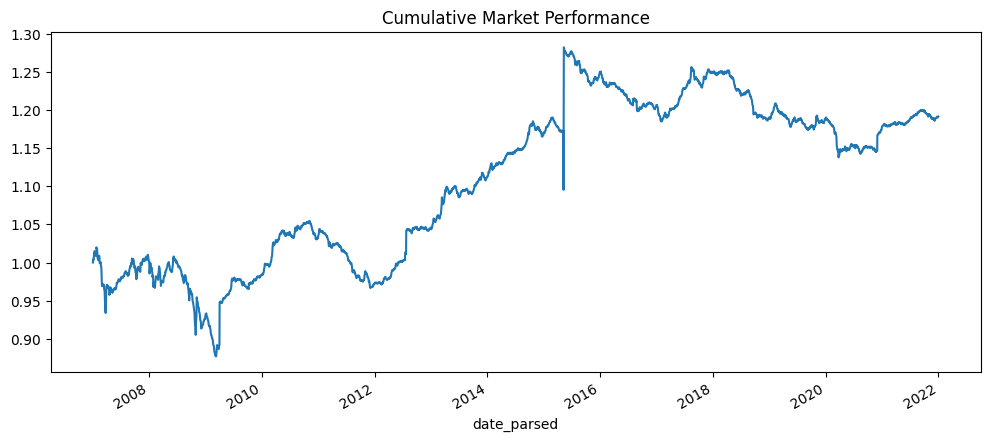

In [59]:
# First ensure sorting
df = cleaning_df.sort_values(['code','date_parsed'])

# Compute returns per stock
df['return'] = df.groupby('code')['day_price'].pct_change()

# Market average return per day
market_return = df.groupby('date_parsed')['return'].mean()

# Market cumulative performance
market_cum = (1+ market_return).cumprod()

# Plotting market cumulative performance
market_cum.plot(figsize= (12,5), title='Cumulative Market Performance');

- The market's performance from 2012 to around 2015 was doing well, however, there was a dip in performance between 2015 and 2016. According to Al Jazeera, the violent lurch lower in stocks was initially triggered by fears that there was an economic slowdown in China, the world's second largest economy. As a result, investors sold shares globally. Additionally, a fall in petroleum prices, the Greek debt default in June 2015, and the effects of the end of quantitative easing in the United States in October 2014 also led to the plunge.

- The stock market continually, did well upto 2020, where it was affected by the COVID-19 virus, but has been recovering since then. We note that there's a steady rise in performance from 2020 to date.

#### *Market Trading Activities*
Here we analysing the trading activities to help us understand the volume trends, market price, how many trades occur per day etc.

##### *Volume Trend*

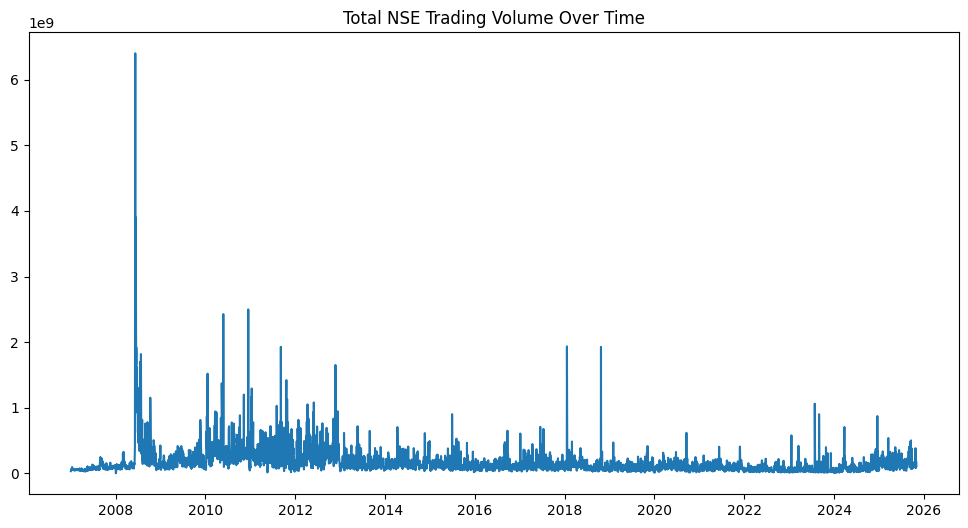

In [60]:
# Market volume over time
market_volume = cleaning_df.groupby('date_parsed')['volume'].sum()

# Plotting 
plt.figure(figsize=(12,6))
plt.plot(market_volume)
plt.title("Total NSE Trading Volume Over Time");

- In the first half of the previous decade, we note thet the volume in the stock market was higher that the first half in the current decade, hinting at the chnages in economies and the markets in general.

- The market was most active from 2008 to about 2018, for almost a decade, and least active from around 2021, after the COVID-19 virus and picked back up towards the end of 2023.

##### *Market Price Over Time*

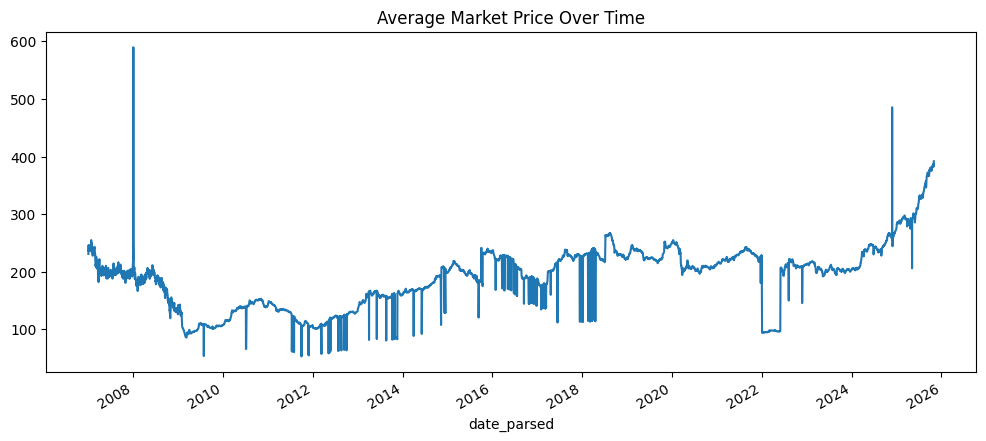

In [61]:
# day_price trend over time
market_trend = cleaning_df.groupby('date_parsed')['day_price'].mean()

# plotting
market_trend.plot(figsize= (12,5), title='Average Market Price Over Time');

- The highest day_price mean was recorded at almost Ksh.600 in 2008, where the lowest was recorded at less that ksh.50 in 2009.

- We note that from around mid-2025, the market price has been on a steady climb from about ksh.300 to around ksh.400.

- Around 2022 towards 2023, there was a plunge in the market price from around ksh.240 to ksh.80, and lasted at least a few months before climbing to around ksh.200.

##### *Number of trades per day*
Analyzing how many trades occurr per day to help us understand if the number of listed companies has been going up or down.

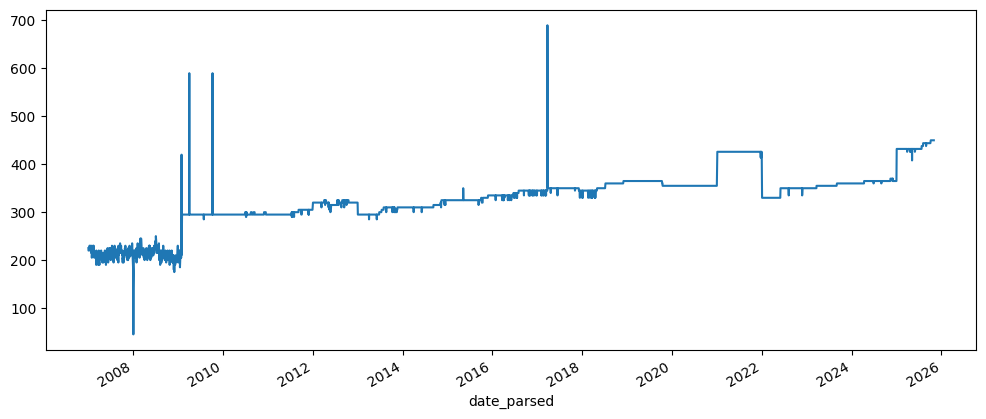

In [62]:
# trades per day
trades = cleaning_df.groupby('date_parsed')['code'].count()

# Plotting
trades.plot(figsize= (12,5));

- There has been a constant rise in the number of trades per day over the years, from sligtly over 40 trades to almost 80 trades. Almost doubling over.

#### *Volume Distribution (Liquidity)*
This helps us understand if the market is liquid or not.

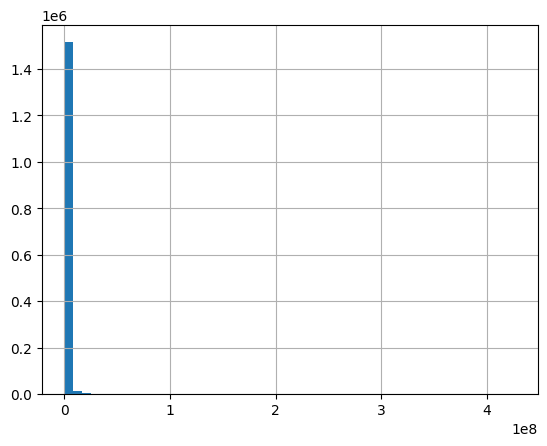

In [63]:
# volume distribution
cleaning_df['volume'].hist(bins= 50);

- The volume distribution is heavily skewed toward lower values, with the majority of trades clustered near zero. This indicates that most stocks in the Nairobi Securities Exchange are relatively illiquid, experiencing low trading activity.

- A small number of observations extend away from 0, suggesting that a few dominant stocks account for the majority of trading activity in the market. This highlights the presence of high concentration in liquidity, where only a handful of stocks drive market activity.

#### *Price Distribution (Market structure)*
This will give us insight into the structure of the market, questioning if most stocks are expensive or cheap.

It will also help us detect outliers.

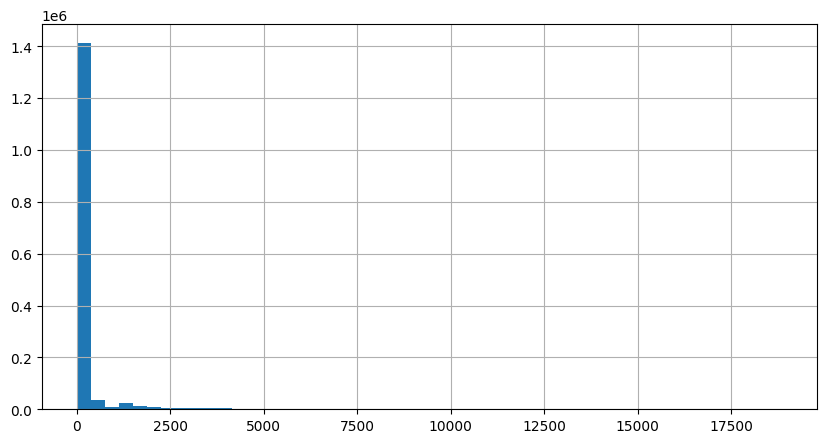

In [64]:
# price distribution
cleaning_df['day_price'].hist(bins= 50, figsize=(10,5));

- The price distribution shows a strong concentration of stocks at lower price levels, with most observations clustered near zero and a smaller number extending up to approximately 2500 and very few past.

- This indicates that the market is dominated by low-priced stocks, with only a few high-value stocks present. Such a distribution is characteristic of emerging markets, where many listed companies have relatively low share prices, while a few large-cap firms trade at significantly higher values.

#### *Price Movement*

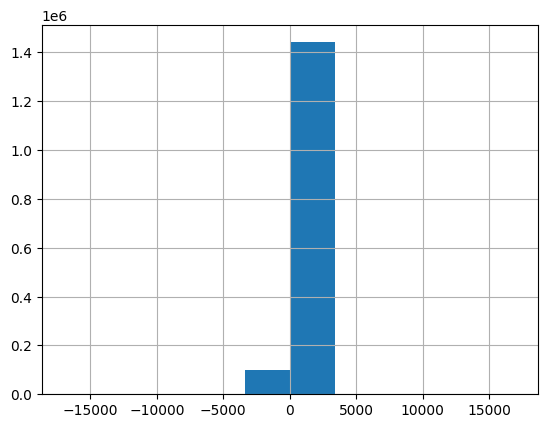

In [65]:
# Price movement
cleaning_df['change'].hist(bins= 10);

- The distribution of price changes is skewed towards positive values, with significantly more observations showing gains than losses. Approximately 290,000 observations fall within the positive range (0 to 3800), compared to fewer than 50,000 in the negative range (-3800 to 0).

- This suggests that, over the observed period, the market exhibited a general upward bias, with stocks more frequently experiencing price increases than declines. This may indicate periods of growth or bullish sentiment within the market.

#### *Correlation Heatmap*
Through this, we seek to understand if prices, volumes and changes correlate with each other.

<Axes: >

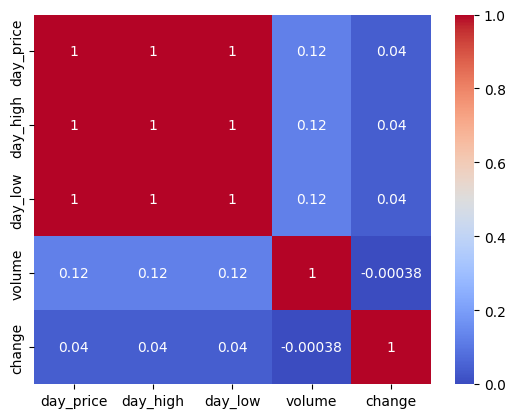

In [66]:
# Columns we need
cols = ['day_price', 'day_high', 'day_low', 'volume', 'change']

# plot heatmap
sns.heatmap(cleaning_df[cols].corr(), annot= True, cmap='coolwarm')

- `day_price`, `day_low` and `day_high` are positively correlated with each other.

- Whereas the other two columns, `volume` and `change` are negatively correlated with the other columns.

#### *Most traded stocks*
This gives us insight as to which companies dominate the market.

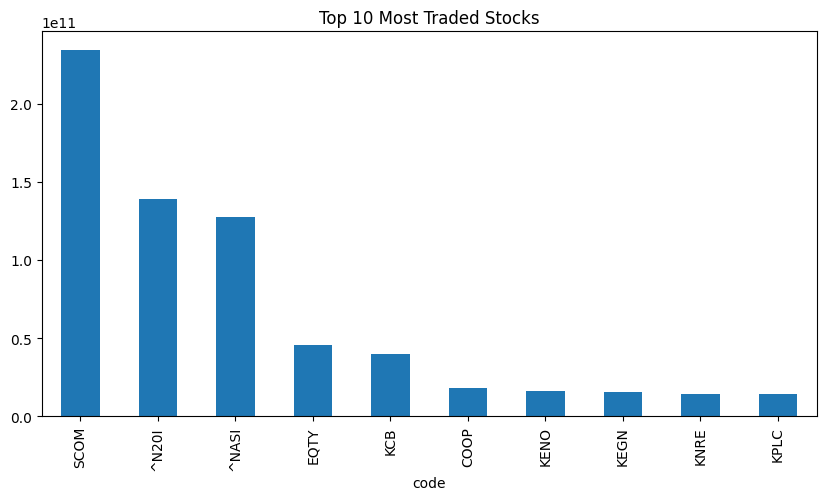

In [67]:
# Fetching the top traded stocks
top_volume = cleaning_df.groupby('code')['volume'].sum().sort_values(ascending=False).head(10)

# plotting
top_volume.plot(kind= 'bar', figsize= (10,5), title= 'Top 10 Most Traded Stocks');

- Safaricom dominates trading volume, indicating it is the most liquid stock on the exchange.
- The indices also dominate the chart.
- Other dominant companies in the exchange include some of the top kenyan banks, Equity Bank, KCB and Cooperative bank.

#### *Most Volatile Stocks*
This helps us identify the most risky stocks at the exchange.

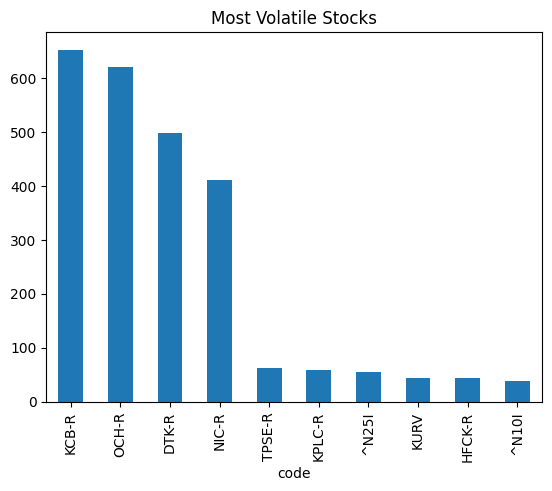

In [68]:
# Fetcing the most volatile stocks
volatility = cleaning_df.groupby('code')['change%'].std().sort_values(ascending= False).head(10)

# Plotting
volatility.plot(kind= 'bar', title= 'Most Volatile Stocks');

- The most volatile stocks in the dataset are predominantly associated with rights issues. These securities tend to exhibit large price fluctuations due to their nature, as they are often issued at discounted prices and are subject to speculative trading.

#### *Top Losers vs Gainers*
Here, we are trying to identify which stocks consistently perform well or poorly.

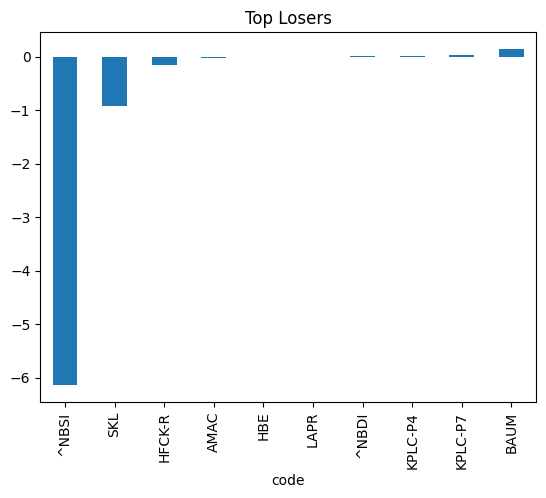

In [69]:
# plotting top losers
cleaning_df.groupby('code')['change%'].mean().sort_values().head(10).plot(kind='bar', title= 'Top Losers');

- We note that on the plot we have 2 indices, indicating that they are consistently the most losing stocks in the market. This is due to their nature as aggregated measures of market performance. Since they are composed of multiple stocks, abroad decline in constituent stocks leads to a decrease in index value.

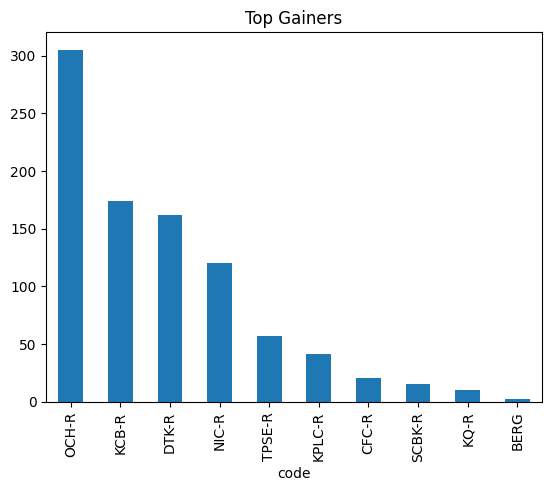

In [70]:
# Top gainers
cleaning_df.groupby('code')['change%'].mean().sort_values(ascending= False).head(10).plot(kind='bar', title= 'Top Gainers');

- We see that 9 out of ten stocks on the plot are rights issue. In addition to right issue stocks being the most volatile, these same stocks appear among the top gainers, indicating that their high volatility is driven by sharp upward price movements. 
- This suggests that corporate actions such as rights issues significantly influence both volatility and short-term returns in the market.

Overall, the analysis reveals a market characterized by low liquidity for most stocks, a concentration of low-priced securities, and a small number of highly active and influential stocks. Market movements appear to be driven largely by a few dominant players and corporate actions such as rights issues, which contribute significantly to volatility and extreme price changes.

### **Company Level Analysis (Safaricom PLC - SCOM)**
Safaricom officially listed and commenced trading on the Nairobi Securities Exchange (NSE) on June 9, 2008, following a public offering (IPO) of 25% of its shares. The IPO, launched earlier on March 28, 2008, was a landmark, offering 10 billion shares at Kshs 5.0 each and increasing total market capitalization.

In this section, we are trying to understand safaricom's stock behaviour, identify its patterns, and prepare ourselves for modeling later.

In the previous analysis level, we noted that Safaricom - SCOM is one of the most traded stocks on the NSE.

First, we are going to filter the data to have safaricom's data for EDA.

In [71]:
# Filter the data
scom = cleaning_df[cleaning_df['code'] == 'SCOM']
scom = pd.DataFrame(scom)

# Review the first 5 rows
scom.head()

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed
13897,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,0.0,-,2008-04-23
15243,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,416380000.0,-,2008-06-09
15285,SCOM,Safaricom,3.1,6.6,6.65,8.0,6.95,7.35,-0.40,5.76,127310000.0,-,2008-06-10
15330,SCOM,Safaricom,3.1,6.6,6.90,7.1,6.95,6.95,0.00,0.00,183490000.0,-,2008-06-11
15374,SCOM,Safaricom,3.1,6.6,7.10,7.5,7.35,6.95,0.40,5.44,131240000.0,-,2008-06-12


In [72]:
# Fetch data summary
scom.info()

<class 'pandas.DataFrame'>
Index: 22133 entries, 13897 to 1537873
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   code            22133 non-null  str           
 1   name            22133 non-null  str           
 2   12m_low         22133 non-null  float64       
 3   12m_high        22133 non-null  float64       
 4   day_low         22133 non-null  float64       
 5   day_high        22133 non-null  float64       
 6   day_price       22133 non-null  float64       
 7   previous        22133 non-null  float64       
 8   change          22133 non-null  float64       
 9   change%         22133 non-null  float64       
 10  volume          22133 non-null  float64       
 11  adjusted_price  22133 non-null  str           
 12  date_parsed     22133 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(9), str(3)
memory usage: 2.4 MB


The data contains values in 14 columns and 4335 rows. All cleaned and in the correct data formats.

#### *Price Trend Over Time*
This helps us understand the price trend of the stock over the observed time. Giving us insights such as;
- is the stock trending up/down?
- are there cycles?

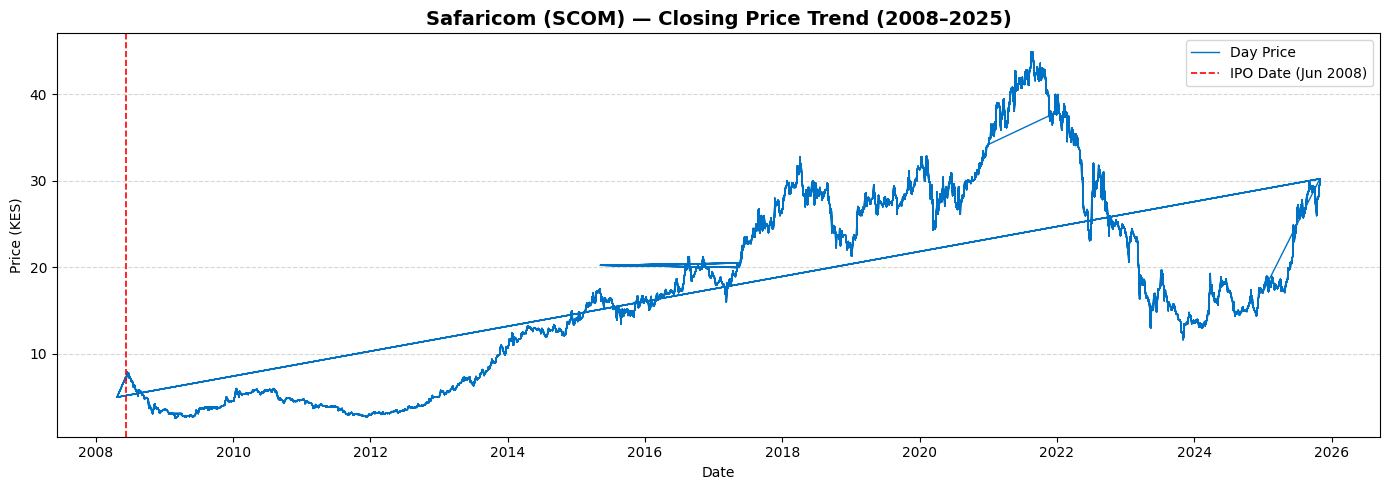

In [73]:
# Safaricom: Closing Price Trend Over Time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(scom['date_parsed'], scom['day_price'], 
        color='#0072C6', linewidth=1, label='Day Price')

# Mark the IPO date as a reference point
ipo_date = pd.Timestamp('2008-06-09')
ax.axvline(x=ipo_date, color='red', linestyle='--', linewidth=1.2, label='IPO Date (Jun 2008)') # type: ignore

ax.set_title('Safaricom (SCOM) — Closing Price Trend (2008–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (KES)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show();

- The stock’s closing price shows distinct phases over time. Between 2008 and around 2013, prices remained relatively low, below 10 KES, indicating a period of low valuation or slow growth.

- From 2014, the stock entered a strong upward trend, rising steadily to peak at over 40 KES around mid-2021. This suggests a period of sustained growth and positive investor sentiment.

- However, from 2021 to 2024, the stock experienced a consistent decline, falling to approximately 12–15 KES, indicating a bearish phase or market correction.

- From 2024 onwards, the price begins to recover, showing a renewed upward trend, reaching around 30 KES by 2025. This suggests a potential recovery phase and improving market confidence.

#### *Volume Over Time*
This analysis helps us identify when the stock is actively traded and whether there are spikes?

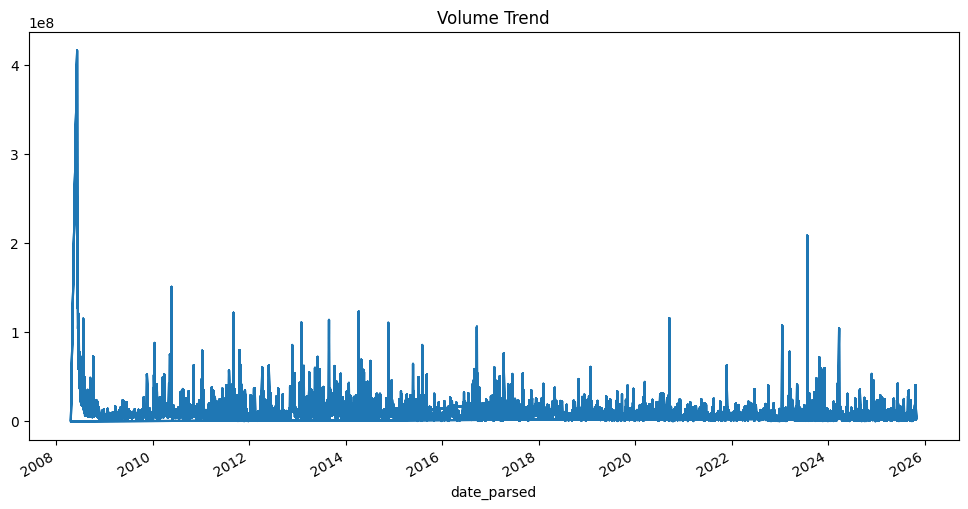

In [74]:
# Volume over time
scom.set_index('date_parsed')['volume'].plot(figsize=(12,6), title= 'Volume Trend');

- Trading volume exhibits a major spike around 2008, reaching very high levels, which may indicate heightened market activity during that period, due to the opening of the stock to the market.

- Beyond this period, volume remains relatively low with occasional spikes, suggesting that the stock is generally less actively traded, with intermittent periods of increased activity. This pattern indicates inconsistent liquidity over time.

#### *Daily Returns*
This will help us identify volatility patterns over the observed time.

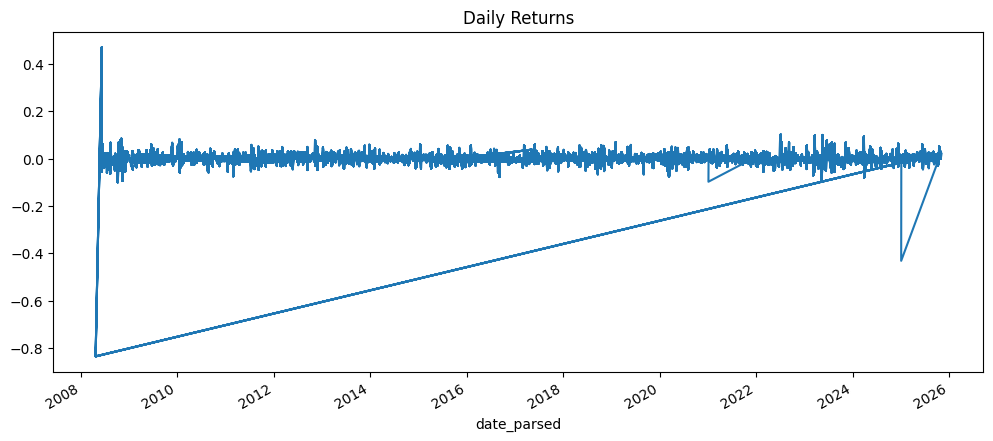

In [75]:
# Create return column
scom['return'] = scom['day_price'].pct_change()

# plotting
scom.set_index('date_parsed')['return'].plot(figsize= (12,5), title= 'Daily Returns');

- Apart from the spike during the initial listing of the stock, the returns have been relatively constant through out the observed period.

- Daily returns are tightly clustered between -0.1 and 0.1, indicating that most price changes are relatively small.

- The absence of extreme spikes suggests that the stock does not experience sudden large price movements frequently, and instead exhibits relatively stable day-to-day fluctuations.

#### *Return Distribution*
We're analysing the returns' distribution over the specified period (2008-2025).

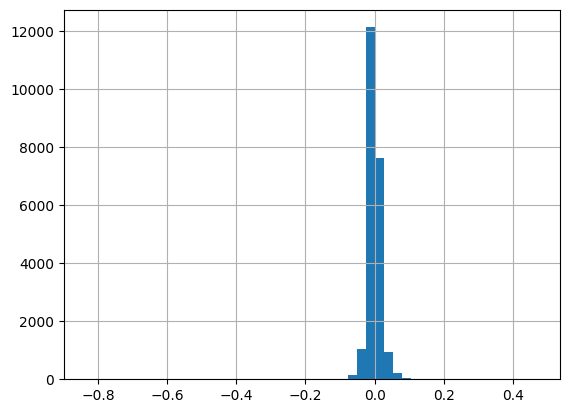

In [76]:
# Return distribution
scom['return'].hist(bins= 50);

- The distribution of returns appears approximately normal, but with a higher concentration of values on the negative side.

- This indicates that while most returns are small and centered around zero, negative returns occur slightly more frequently than positive ones. This suggests a mild downward bias in price movements over the observed period.

#### *Rolling Mean*
By carrying out this analysis, we are trying to identify the underlying trends, as well as noise vs movement analysis.

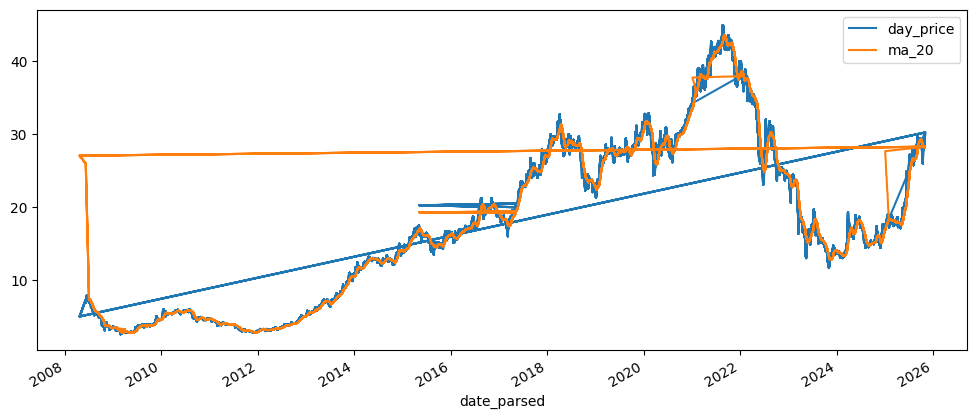

In [77]:
# finding rolling mean
scom['ma_20'] = scom['day_price'].rolling(window=20).mean()

# plotting
scom.set_index('date_parsed')[['day_price', 'ma_20']].plot(figsize= (12,5));

- The plot suggests that there isn't any underlying trends in the stock.

#### *Rolling Volatility*
This will help us identify;
- when the stock is risky
- stable vs unstable periods

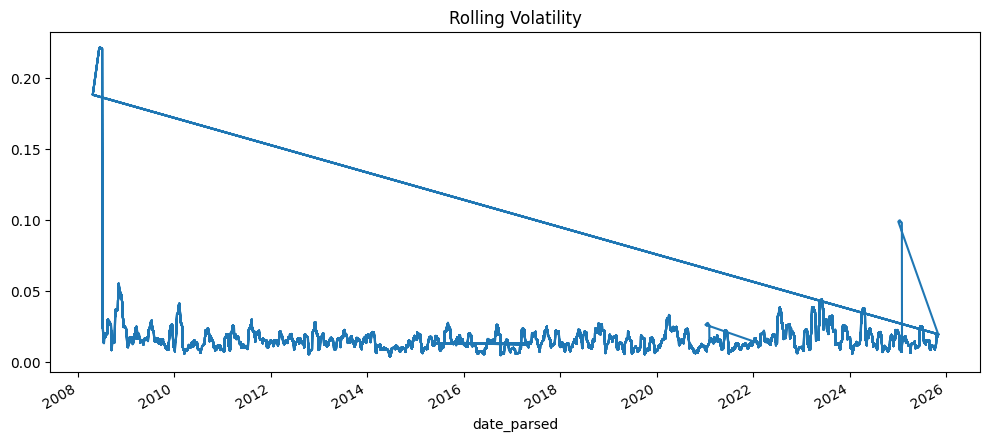

In [78]:
# adding rolling volatility column
scom['volatility'] = scom['return'].rolling(window=20).std()

# plotting rolling volatility
scom.set_index('date_parsed')['volatility'].plot(figsize= (12,5), title= 'Rolling Volatility');

- Rolling volatility remains relatively low and stable throughout the observed period, fluctuating within a narrow range.

- The absence of significant spikes suggests that the stock does not experience periods of extreme uncertainty or risk, and maintains relatively consistent levels of volatility over time.

#### *`day_low` vs `day_high` Relationship*

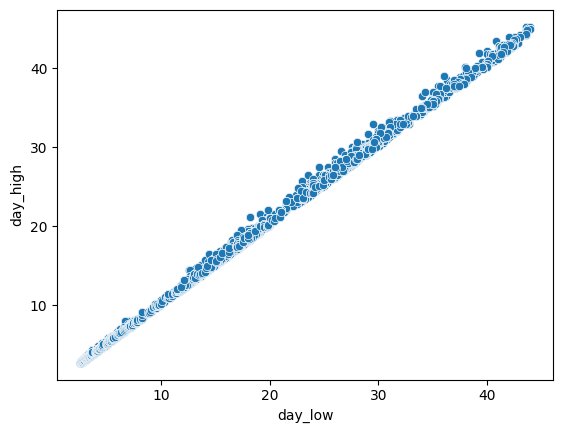

In [79]:
# plotting
sns.scatterplot(data= scom, x= 'day_low', y= 'day_high');

- There is a strong positive relationship between day low and day high prices, as expected. The near-linear pattern indicates that when the lowest price of the day increases, the highest price also increases proportionally.

- This reflects consistent intraday price movement and confirms the internal coherence of the dataset.

#### *Price Range (Intraday Volatility)*
This helps us understand how much price fluctuates daily.

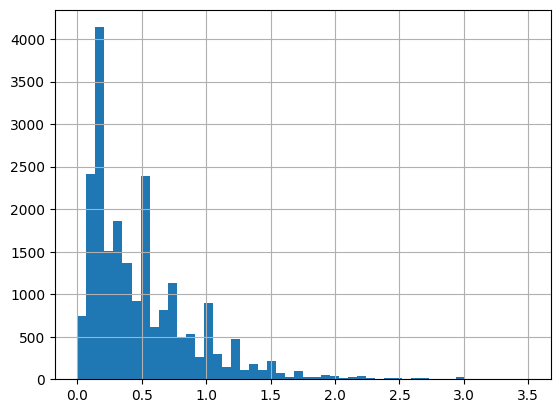

In [80]:
# add range column
scom['range'] = scom['day_high'] - scom['day_low']

# plotting
scom['range'].hist(bins= 50);

- The distribution of daily price range is heavily right-skewed, with most values clustered between 0 and 0.5 KES.

- This indicates that the majority of trading days experience minimal price fluctuation, suggesting low intraday volatility.

- However, a few extreme values (up to around 3 KES) are observed, representing rare but significant price movements. These can be considered outliers and may correspond to unusual market events.

#### *Price Distribution*

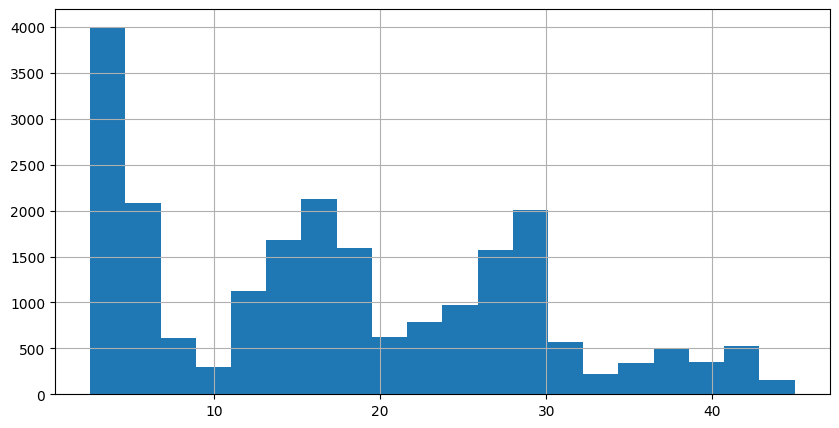

In [81]:
scom['day_price'].hist(bins= 20, figsize=(10,5));

- The price distribution is right-skewed, with concentration of observations in between, between ksh10 and ksh20 and also between ks20 and ksh30.

This indicates that the stock spends most of its time trading at lower prices, with fewer instances of high price levels, ksh40. Such a distribution reflects periods of gradual growth followed by peaks that are less frequently sustained.


#### *`volume` vs `day_price` Relationship*
Does high trading volume affect pricing?

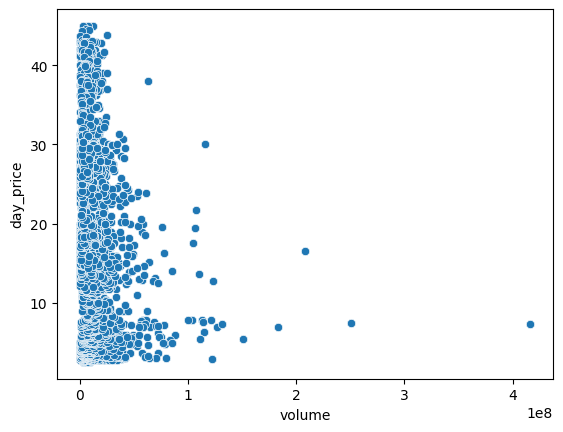

In [82]:
# Plotting
sns.scatterplot(data= scom, x='volume', y='day_price');

- The scatter plot of volume versus price shows a heavy concentration of observations near zero volume, indicating that most trading days involve low activity regardless of price level.

- There is no clear relationship between volume and price, suggesting that increases in trading activity do not consistently correspond to higher or lower prices.

- This implies that price movements are not strongly driven by trading volume, and the stock may experience price changes even during periods of low liquidity.

#### *SCOM Correlation Heatmap*

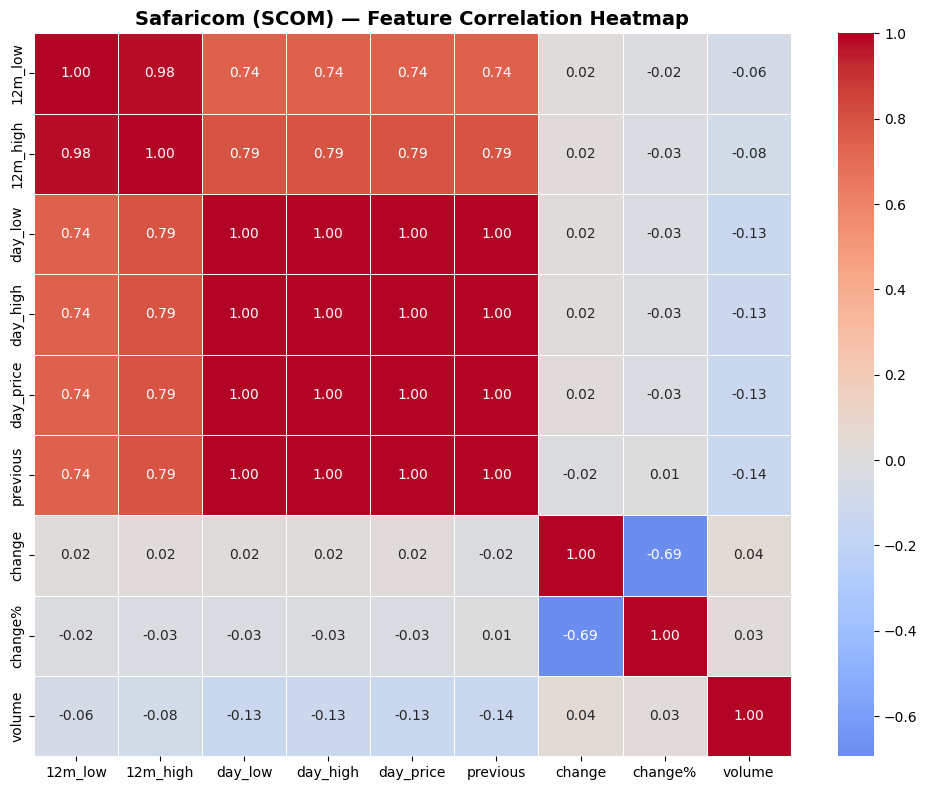

In [83]:
# Safaricom: Correlation Heatmap
# Select only numeric columns for the heatmap
scom_numeric = scom[['12m_low', '12m_high', 'day_low', 'day_high', 
                           'day_price', 'previous', 'change', 'change%', 'volume']]

corr_matrix = scom_numeric.corr() # type: ignore

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title('Safaricom (SCOM) — Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

- The heatmap shows how strongly the numeric columns move together. For modelling, we want to understand:
    - Which features are highly correlated with day_price (target)
    - Which features are correlated with each other (multicollinearity)
    - important for linear models.


#### **Company Level Summary**
Although the volume over time distribution in the analysis above appears relatively low, this is largely due to the presence of extreme spikes, particularly during the initial listing period of Safaricom.

Safaricom, being the most actively traded stock on the Nairobi Securities Exchange, experienced exceptionally high trading volumes during its IPO around 2008, when shares were widely purchased by the public.

These extreme values skew the distribution, making typical trading volumes appear relatively small in comparison. In reality, the stock maintains consistently high trading activity over time, with periodic spikes reflecting increased market interest.

Therefore, the apparent low-volume clustering does not indicate low liquidity, but rather the effect of scale and outliers in the dataset.

In [84]:
# Delete every unnecesary column in preparation to feature engineering
scom = scom.drop(columns= ['return', 'ma_20', 'volatility', 'range'])

##  **Feature Engineering**

Based on our EDA findings, we now engineer features that will be used to predict
the **next-day closing price** of a stock (`target: next_day_close`).

The features we build fall into four categories:

| Category | Features | Why |
|---|---|---|
| **Target** | `next_day_close` | What we are predicting |
| **Lag features** | `lag_1` to `lag_7` | Yesterday's price is the strongest predictor of today's |
| **Rolling averages** | `ma_7`, `ma_30` | Capture short and medium-term trend direction |
| **Return & Volatility** | `daily_return`, `volatility_7`, `volatility_30` | Capture momentum and risk |
| **Price range** | `day_range`, `range_position` | Capture intraday buying/selling pressure |


> All features are computed **per stock** using `groupby('code')` to prevent
> data leakage between different companies.

- Exclude the features starting with (^) as they are not tradable 

In [85]:
# Work on a clean copy so scom stays untouched
scom_df = scom.copy()

# Sort by stock code and date — critical for correct lag/rolling calculations
scom_df = scom_df.sort_values(['code', 'date_parsed']).reset_index(drop=True)

In [86]:
# Inspect data summary
scom.info()

<class 'pandas.DataFrame'>
Index: 22133 entries, 13897 to 1537873
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   code            22133 non-null  str           
 1   name            22133 non-null  str           
 2   12m_low         22133 non-null  float64       
 3   12m_high        22133 non-null  float64       
 4   day_low         22133 non-null  float64       
 5   day_high        22133 non-null  float64       
 6   day_price       22133 non-null  float64       
 7   previous        22133 non-null  float64       
 8   change          22133 non-null  float64       
 9   change%         22133 non-null  float64       
 10  volume          22133 non-null  float64       
 11  adjusted_price  22133 non-null  str           
 12  date_parsed     22133 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(9), str(3)
memory usage: 2.4 MB


In [87]:
# Review first 5 rows
scom_df.head()

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed
0,SCOM,Safaricom,3.1,6.6,5.0,5.0,5.0,29.75,-24.75,495.0,0.0,-,2008-04-23
1,SCOM,Safaricom,3.1,6.6,5.0,5.0,5.0,29.75,-24.75,495.0,0.0,-,2008-04-23
2,SCOM,Safaricom,3.1,6.6,5.0,5.0,5.0,29.75,-24.75,495.0,0.0,-,2008-04-23
3,SCOM,Safaricom,3.1,6.6,5.0,5.0,5.0,29.75,-24.75,495.0,0.0,-,2008-04-23
4,SCOM,Safaricom,3.1,6.6,5.0,5.0,5.0,29.75,-24.75,495.0,0.0,-,2008-04-23


### **Creating New Columns**
#### *Target Variable*
 - next_day_close: the closing price of the NEXT trading day.
 - We shift day_price by -1 within each stock group.
 - The last row per stock will be NaN (no future price exists)  and will be dropped later.

In [88]:
# add next day close column
scom_df['next_day_close'] = scom_df.groupby('code')['day_price'].shift(-1)

#### *Lag Features*
 - Lag features give the model "memory" of recent prices.
 - lag_1 = yesterday's close, lag_2 = 2 days ago, etc.
 - These are the most predictive features for any price model.

In [89]:
# add lag features column
for lag in [1, 2, 3, 5, 7, 11]:
    scom_df[f'lag_{lag}'] = scom_df.groupby('code')['day_price'].shift(lag)

#### *Rolling Averages (MA7, MA30)*
 - MA7 captures short-term price momentum (one trading week).
 - MA30 captures medium-term trend (roughly one trading month).
 - min_periods=1 avoids NaN at the very start of a stock's history.

In [90]:
# add rolling averages columns
scom_df['ma_7'] = (
    scom_df.groupby('code')['day_price']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
)

scom_df['ma_30'] = (
    scom_df.groupby('code')['day_price']
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean().shift(1))
)

scom_df['ma_ratio'] = scom_df['ma_7'] / scom_df['ma_30']

#### *Daily Return & Rolling Volatility*
 - daily_return: percentage change from previous close to today's close. - This normalizes price movements across stocks of different price levels.
 
 - volatility_7 / volatility_30: rolling standard deviation of daily returns. - This captures how "risky" or erratic a stock has been recently — an important signal that models can use to adjust their predictions.


In [91]:
# adding daily returns and rolling volatility columns
scom_df['daily_return'] = (
    scom_df.groupby('code')['day_price']
    .transform(lambda x: x.pct_change())
)

scom_df['volatility_7'] = (
    scom_df.groupby('code')['daily_return']
    .transform(lambda x: x.rolling(window=7, min_periods=1).std().shift(1))
)

scom_df['volatility_30'] = (
    scom_df.groupby('code')['daily_return']
    .transform(lambda x: x.rolling(window=30, min_periods=1).std().shift(1))
)

#### *Price Range Features*
 - day_range: the full intraday price swing (high - low).- A wide range signals high volatility on that specific day.

 - range_position: where the closing price sits within the day's range. - A value close to 1.0 means the stock closed near its daily high (bullish signal). A value close to 0.0 means it closed near the daily low (bearish signal).

We add a small epsilon (1e-9) to avoid division by zero on flat days.

In [92]:
# add price range column
scom_df['day_range'] = scom_df['day_high'] - scom_df['day_low']

scom_df['range_position'] = (
    (scom_df['day_price'] - scom_df['day_low']) / 
    (scom_df['day_range'] + 1e-9)
)

print("Features created successfully.")
print(f"Shape before dropping NaNs: {scom_df.shape}")

Features created successfully.
Shape before dropping NaNs: (22133, 28)


In [93]:
# add a next day return column as the target variable
scom_df['next_day_return'] = scom_df.groupby('code')['day_price'].transform(lambda x: x.pct_change().shift(-1))                 

#### *Volume Features*
- These will help the models capture market activity spikes, which is very important for active stocks.

In [94]:
# add volume features
scom_df['volume_ma_5'] = (scom_df.groupby('code')['volume'].transform(lambda x: x.rolling(5).mean()).shift(1))

scom_df['volume_change'] = scom_df.groupby('code')['volume'].pct_change()

#### *Momentum Features*
- This feature will help the model measure short term trends strength.

In [95]:
# add momentum features
scom_df['momentum_5'] = scom_df.groupby('code')['day_price'].pct_change(5)
scom_df['momentum_10'] = scom_df.groupby('code')['day_price'].pct_change(10)

#### *Rolling min/max*
By adding these features, we allow the creation of the price position feature, allowing us to meausre support and resistance in the market.

In [96]:
scom_df['rolling_max_10'] = (scom_df.groupby('code')['day_price'].transform(lambda x: x.rolling(10).max()).shift(1))
scom_df['rolling_min_10'] = (scom_df.groupby('code')['day_price'].transform(lambda x: x.rolling(10).min()).shift(1))


scom_df['price_position'] = (scom_df['day_price'] - scom_df['rolling_min_10']) / (scom_df['rolling_max_10'] - scom_df['rolling_min_10'] + 1e-9)

In [97]:
# review first 10 rows
scom_df.head(10)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,...,day_range,range_position,next_day_return,volume_ma_5,volume_change,momentum_5,momentum_10,rolling_max_10,rolling_min_10,price_position
0,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,...,0.00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,...,0.00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,...,0.00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,...,0.00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SCOM,Safaricom,3.1,6.6,5.00,5.0,5.00,29.75,-24.75,495.00,...,0.00,0.000000,0.470000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,...,1.05,0.380952,0.000000,0.0,inf,0.47,NaN,NaN,NaN,NaN
6,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,...,1.05,0.380952,0.000000,83276000.0,0.0,0.47,NaN,NaN,NaN,NaN
7,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,...,1.05,0.380952,0.000000,166552000.0,0.0,0.47,NaN,NaN,NaN,NaN
8,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,...,1.05,0.380952,0.000000,249828000.0,0.0,0.47,NaN,NaN,NaN,NaN
9,SCOM,Safaricom,3.1,6.6,6.95,8.0,7.35,5.00,2.35,31.97,...,1.05,0.380952,-0.054422,333104000.0,0.0,0.47,NaN,NaN,NaN,NaN


- Drop rows with NaN in critical feature/target columns because Lag features create NaN for the first N rows of each stock (e.g., lag_7 needs 7 prior rows before it has a value).
- The target also creates NaN for the LAST row of each stock.

In [98]:
# Columns that must not be NaN for training
critical_cols = ['next_day_close', 'lag_1', 'lag_2', 'lag_3', 
                 'lag_5', 'lag_7', 'ma_7', 'ma_30',
                 'daily_return', 'volatility_7', 'volatility_30',
                 'day_range', 'range_position','next_day_return']

scom_df = scom_df.dropna(subset=critical_cols).reset_index(drop=True)

print(f"Shape after dropping NaNs: {scom_df.shape}")
print(f"Unique stocks remaining: {scom_df['code'].nunique()}")

Shape after dropping NaNs: (22125, 36)
Unique stocks remaining: 1


In [99]:
# Inspect the final feature columns and a sample

feature_cols = ['date_parsed', 'code', 'name', 'day_price', 'next_day_close',
                'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7',
                'ma_7', 'ma_30', 'daily_return','next_day_return', 'volatility_7', 
                'volatility_30', 'day_range', 'range_position', 'volume']

print("Final feature columns:")
print(feature_cols)
print()

scom_df[feature_cols].head(10)

Final feature columns:
['date_parsed', 'code', 'name', 'day_price', 'next_day_close', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'ma_7', 'ma_30', 'daily_return', 'next_day_return', 'volatility_7', 'volatility_30', 'day_range', 'range_position', 'volume']



,date_parsed,code,name,day_price,next_day_close,lag_1,lag_2,lag_3,lag_5,lag_7,ma_7,ma_30,daily_return,next_day_return,volatility_7,volatility_30,day_range,range_position,volume
0,2008-06-09,SCOM,Safaricom,7.35,7.35,7.35,7.35,5.00,5.00,5.00,5.671429,5.671429,0.000000,0.000000,0.191877,0.191877,1.05,0.380952,416380000.0
1,2008-06-09,SCOM,Safaricom,7.35,7.35,7.35,7.35,7.35,5.00,5.00,6.007143,5.881250,0.000000,0.000000,0.177643,0.177643,1.05,0.380952,416380000.0
2,2008-06-09,SCOM,Safaricom,7.35,6.95,7.35,7.35,7.35,5.00,5.00,6.342857,6.044444,0.000000,-0.054422,0.177643,0.166170,1.05,0.380952,416380000.0
3,2008-06-10,SCOM,Safaricom,6.95,6.95,7.35,7.35,7.35,7.35,5.00,6.678571,6.175000,-0.054422,0.000000,0.177643,0.156667,1.35,0.222222,127310000.0
4,2008-06-10,SCOM,Safaricom,6.95,6.95,6.95,7.35,7.35,7.35,5.00,6.957143,6.245455,0.000000,0.000000,0.182204,0.151508,1.35,0.222222,127310000.0
5,2008-06-10,SCOM,Safaricom,6.95,6.95,6.95,6.95,7.35,7.35,7.35,7.235714,6.304167,0.000000,0.000000,0.182204,0.144278,1.35,0.222222,127310000.0
6,2008-06-10,SCOM,Safaricom,6.95,6.95,6.95,6.95,6.95,7.35,7.35,7.178571,6.353846,0.000000,0.000000,0.020569,0.137995,1.35,0.222222,127310000.0
7,2008-06-10,SCOM,Safaricom,6.95,6.95,6.95,6.95,6.95,7.35,7.35,7.121429,6.396429,0.000000,0.000000,0.020569,0.132469,1.35,0.222222,127310000.0
8,2008-06-11,SCOM,Safaricom,6.95,6.95,6.95,6.95,6.95,6.95,7.35,7.064286,6.433333,0.000000,0.000000,0.020569,0.127559,0.20,0.250000,183490000.0
9,2008-06-11,SCOM,Safaricom,6.95,6.95,6.95,6.95,6.95,6.95,7.35,7.007143,6.465625,0.000000,0.000000,0.020569,0.123157,0.20,0.250000,183490000.0


In [100]:

print(f"Safaricom feature rows: {scom_df.shape[0]}")
print(f"Date range: {scom_df['date_parsed'].min()} → {scom_df['date_parsed'].max()}")

Safaricom feature rows: 22125
Date range: 2008-06-09 00:00:00 → 2025-10-31 00:00:00


In [101]:
# Save feature-engineered datasets to processed folder

#   1. scom_features.csv       — Safaricom only (for primary modelling)
scom_df.to_csv("../data/raw_data/processed/scom_features.csv", index=False)

print("Saved: scom_features.csv")

Saved: scom_features.csv


### **Feature Engineering Summary**
Feature engineering was performed to transform raw stock data into meaningful predictive signals.

These features include lagged returns to capture temporal dependencies, moving averages to identify trends, rolling volatility to measure risk, and momentum indicators to capture price direction.

Volume-based features were also included to account for market activity, while rolling minimum and maximum values were used to approximate support and resistance levels.

These engineered features provide the model with both historical context and market dynamics necessary for accurate prediction.

| Feature | Type | Notes |
|---|---|---|
| `next_day_close` | Target | Shift(-1) per stock group |
| `lag_1` → `lag_7` | Lag | Price memory - strongest predictors |
| `ma_7`, `ma_30` | Rolling mean | Short & medium-term trend |
| `daily_return` | Derived | % change from previous close |
| `volatility_7`, `volatility_30` | Rolling std | Recent risk signal |
| `day_range` | Derived | Intraday high - low spread |
| `range_position` | Derived | Close position within day range (0–1) |



## **Data Preprocessing**
This section ensures we prepare our features for a model to learn properly. We have already worked on our data by cleaning and analyzing it. 

This process will include;
- selecting features + target
- splitting into train and test datasets
- scaling
- ensuring the data is clean for modeling

#### *Feature Selection*
We are choosing the actual features we need for machine learning. During feature engineering, we engineered some of the most important features we need for modeling. Here we will be dividing them into two;
- Target variable - this is what we will be trying to predict.
     - `next_day_close`

- Feature - these are the features we shall be using to help us predict the next day prices.
     - `lag_2`, `lag_3`, `lag_5`, `lag_7`, `lag_11`, `ma_7`, `ma_30`, `ma_ratio`, `daily_return`,
       `volatility_7`, `volatility_30`, `day_range`, `volume_ma_5`, `volume_change`, `momentum_5`, `momentum_10`,
       `price_position` etc.

In [102]:
# features
features = ['lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_11', 'ma_7', 'ma_30', 'ma_ratio', 'daily_return',
       'volatility_7', 'volatility_30', 'day_range','volume_ma_5', 'volume_change', 'momentum_5', 'momentum_10',
       'rolling_max_10', 'rolling_min_10', 'range_position']

X = scom_df[features].shift(1)

# target
y = scom_df['next_day_return']

# combine and remove missing values
data = pd.concat([X, y], axis=1).dropna()

# redefine X and y
X = data[features]
y = data['next_day_return']

print(X.shape)
print(y.shape)

(22120, 19)
(22120,)


#### *Time-Based Train/Test Split*
Because this will be a time-series prediction/ we are predicting the future, random splitting is not recommended, therefore we will be performing a chronological split, meaning that training must only be don eon past data only.

In [103]:
# create 70:15:15 split
n = len(data)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train = data.iloc[:train_size]
val = data[train_size:train_size + val_size]
test = data[train_size + val_size:]

# split into features and target
X_train = train[features]
y_train = train['next_day_return']

X_val = val[features]
y_val = val['next_day_return']

X_test = test[features]
y_test = test['next_day_return']

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(15483, 19)
(3318, 19)
(3319, 19)


In [104]:
X_train.isna().sum()

lag_2             0
lag_3             0
lag_5             0
lag_7             0
lag_11            0
ma_7              0
ma_30             0
ma_ratio          0
daily_return      0
volatility_7      0
volatility_30     0
day_range         0
volume_ma_5       0
volume_change     0
momentum_5        0
momentum_10       0
rolling_max_10    0
rolling_min_10    0
range_position    0
dtype: int64

In [105]:
# train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]


In [106]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(15483, 19) (15483,)
(3318, 19) (3318,)
(3319, 19) (3319,)


#### *Scaling*
During EDA, we noted some outliers, for standardization, we are going to scale the features.

Also, due to the fact that most features have different scales, we are going to scale everything.

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### **Summary**
The dataset was prepared for modeling by selecting relevant engineered features and defining the target variable.

A time-based train-test split was applied to preserve the temporal structure of the data, ensuring that the model is trained on past data and evaluated on future observations.

Feature scaling was performed to standardize the input variables, allowing the model to learn effectively from features with different magnitudes.

## **Modeling**

### **Baseline Model**

A naive baseline model is implemented for comparison purposes.

The naive approach assumes that tomorrow's return will be similar to the previous observed return.

This benchmark helps determine whether machine learning models provide meaningful predictive improvement.

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# naive prediction using lag_2
naive_pred = X_val['lag_2']

mae_naive = mean_absolute_error(y_val, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_val, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 33.65120001315502
Naive RMSE: 34.43578411190181


This is a baseline model using linear regression that predicts raw prices
 **Linear Regression Model**

Linear Regression is used as the primary baseline machine learning model.

This model assumes linear relationships between engineered financial indicators and future stock returns.

The simplicity of Linear Regression often makes it robust in noisy financial datasets.

In [109]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_val_scaled)

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

MAE: 0.0028442136017310026
RMSE: 0.007505545805815782


**R² Score Evaluation**

The R² score measures how much variance in the target variable is explained by the model.

In financial prediction tasks, low R² values are common because stock returns contain significant randomness and noise.

In [111]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_val, y_pred_lr)

print("Linear Regression R²:", r2_lr)

Linear Regression R²: 0.021051385410562395


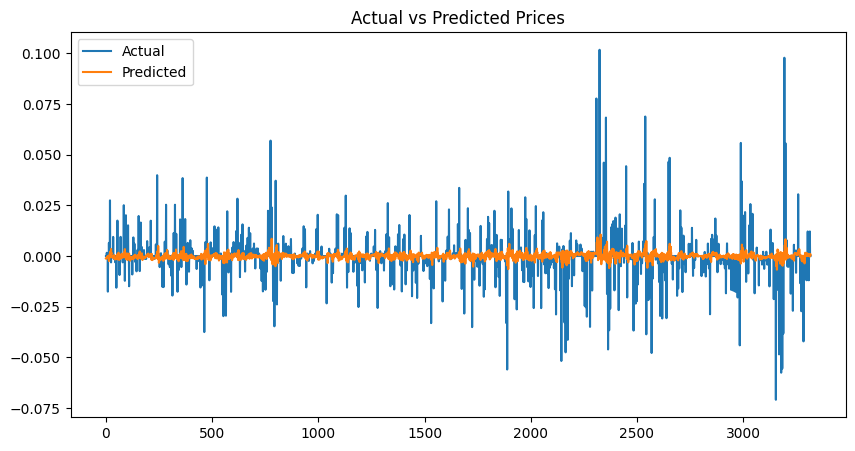

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_val.values, label='Actual')
plt.plot(y_pred_lr, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Prices')
plt.show()



### **Directional Accuracy**

Directional accuracy measures how often the model correctly predicts whether the stock return will be positive or negative.

In finance, predicting direction correctly is often more valuable than predicting exact return values.

In [113]:
direction_actual = (y_val > 0).astype(int)
direction_pred = (y_pred_lr > 0).astype(int)

direction_accuracy = (direction_actual == direction_pred).mean()

print("Direction Accuracy:", direction_accuracy)

Direction Accuracy: 0.5382760699216396


### **Residual Analysis**

Residuals represent the difference between actual and predicted values.

Analyzing residuals helps determine:
- Whether the model is biased
- Whether patterns remain unexplained
- Whether errors behave randomly

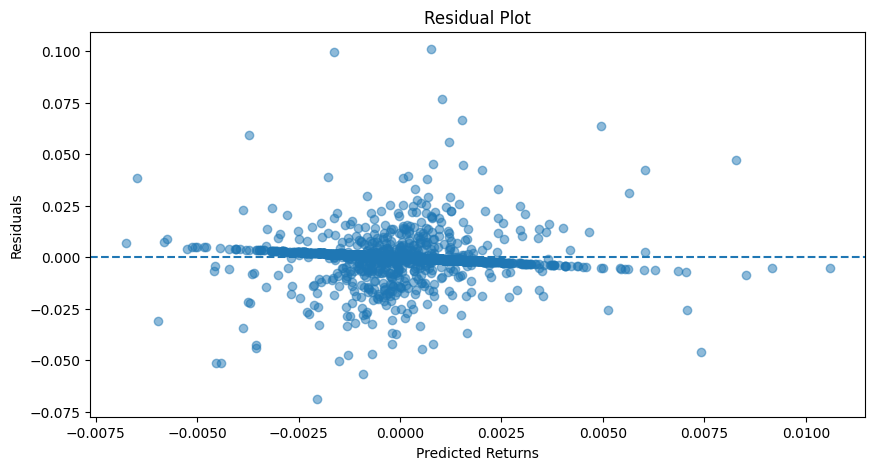

In [114]:
import matplotlib.pyplot as plt

residuals = y_val - y_pred_lr

plt.figure(figsize=(10,5))
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Returns")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### **Error Distribution**

This visualization shows the distribution of prediction errors.

A well-performing model should produce residuals centered around zero without strong skewness.

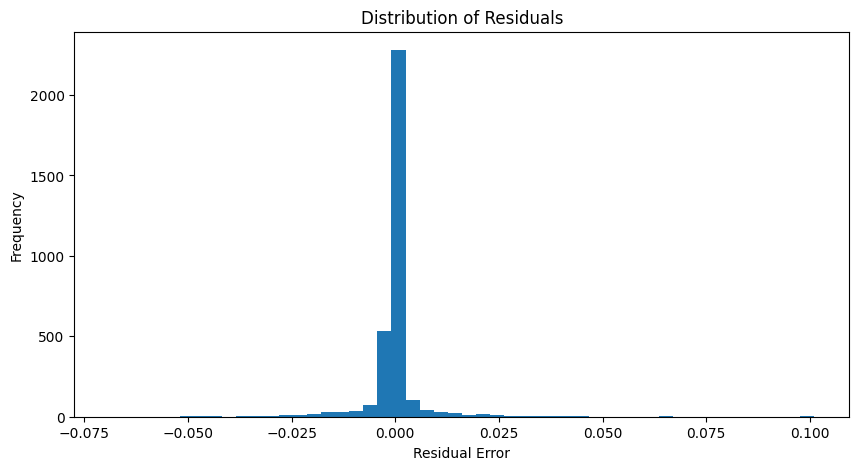

In [115]:
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=50)
plt.title("Distribution of Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.show()

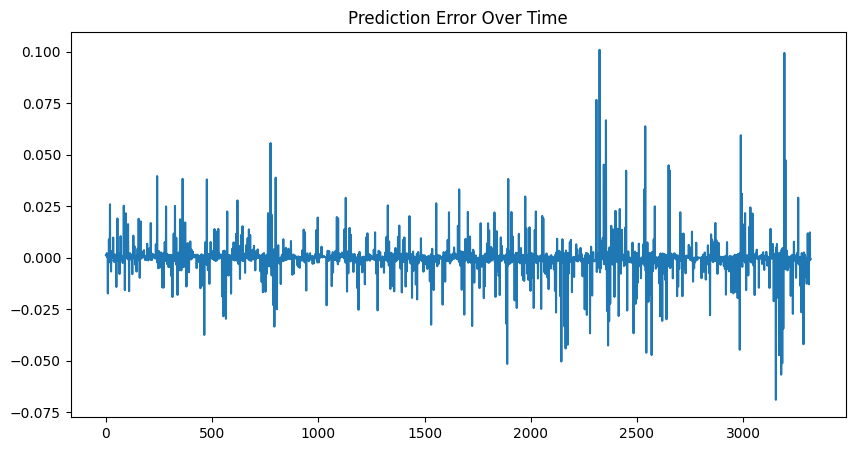

In [116]:
error = y_val - y_pred_lr

plt.figure(figsize=(10,5))
plt.plot(error.values)
plt.title("Prediction Error Over Time")
plt.show()

Here with using the lag features we get the perfomance of the model to be too well where by it is eaning price continuity and not true prediction
I also removed `lag 1` but there was minimal change whuch proves redundancy in features

Next i will switch from price prediction to Returns and see how it will fare on


In [117]:
y2 = scom_df['next_day_return']

In [118]:
# create 70:15:15 chronological split
n = len(scom_df)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train = scom_df.iloc[:train_size]
val = scom_df[train_size:train_size + val_size]
test = scom_df[train_size + val_size:]

# split the data
X_train, y_train = train[features], train['next_day_return']
X_val, y_val = val[features], val['next_day_return']
X_test, y_test = test[features], test['next_day_return']

In [119]:
X_train.isna().sum()

lag_2             0
lag_3             0
lag_5             0
lag_7             0
lag_11            4
ma_7              0
ma_30             0
ma_ratio          0
daily_return      0
volatility_7      0
volatility_30     0
day_range         0
volume_ma_5       0
volume_change     0
momentum_5        0
momentum_10       3
rolling_max_10    3
rolling_min_10    3
range_position    0
dtype: int64

In [120]:
# train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]


In [121]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(15483, 19) (15483,)
(3318, 19) (3318,)
(3320, 19) (3320,)


In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [123]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.0028448427395857045
RMSE: 0.0075367982264334206


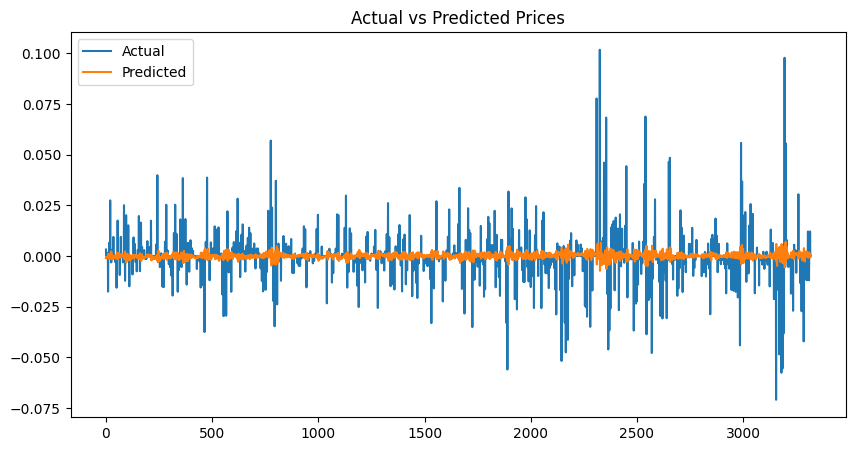

In [125]:
plt.figure(figsize=(10,5))
plt.plot(y_val.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Prices')
plt.show()



In [126]:
print("MAE:", mae)
print("RMSE:", rmse)
print("Mean return:", y_val.mean())

MAE: 0.0028448427395857045
RMSE: 0.0075367982264334206
Mean return: -0.00015926262070522674


In [127]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2,
    reg_lambda=2,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [128]:
y_pred_xgb = xgb_model.predict(X_val)

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.002285210321862572
XGBoost RMSE: 0.007576669854934344


In [130]:
print("Linear MAE:", mae)
print("XGBoost MAE:", mae_xgb)

print("Linear RMSE:", rmse)
print("XGBoost RMSE:", rmse_xgb)

Linear MAE: 0.0028448427395857045
XGBoost MAE: 0.002285210321862572
Linear RMSE: 0.0075367982264334206
XGBoost RMSE: 0.007576669854934344


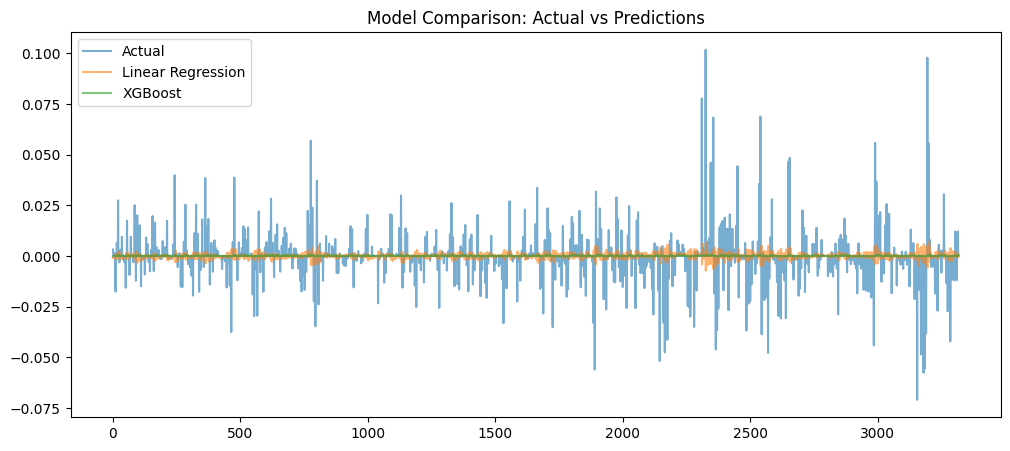

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_val.values, label='Actual', alpha=0.6)
plt.plot(y_pred, label='Linear Regression', alpha=0.6)
plt.plot(y_pred_xgb, label='XGBoost', alpha=0.6)
plt.legend()
plt.title("Model Comparison: Actual vs Predictions")
plt.show()

Although XGBoost is a more complex model, it did not outperform Linear Regression in this case. This suggests that the underlying relationships in the data are largely linear, and that more complex models may overfit noise rather than capture meaningful patterns. This highlights the efficient market nature of stock returns, where predictability is limited.

In [132]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, y_pred)

print("R² Score:", r2)

R² Score: 0.012940483619771737


### **Random Forest Model**

Random Forest is an ensemble learning model that combines multiple decision trees to improve prediction stability and reduce variance.

In [133]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [134]:
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest MAE: 0.0026188286256345742
Random Forest RMSE: 0.007601576738296409


### Model Comparison Table

In [135]:
comparison = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression', 'XGBoost', 'Random Forest'],
    'MAE': [mae_naive, mae_lr, mae_xgb, mae_rf],
    'RMSE': [rmse_naive, rmse_lr, rmse_xgb, rmse_rf]
})

comparison

,Model,MAE,RMSE
0,Naive,33.651200,34.435784
1,Linear Regression,0.002844,0.007506
2,XGBoost,0.002285,0.007577
3,Random Forest,0.002619,0.007602


## **Feature Importance Analysis**

Feature importance analysis helps identify which engineered financial indicators contribute most to model predictions.

This provides insight into the drivers of stock market behavior.

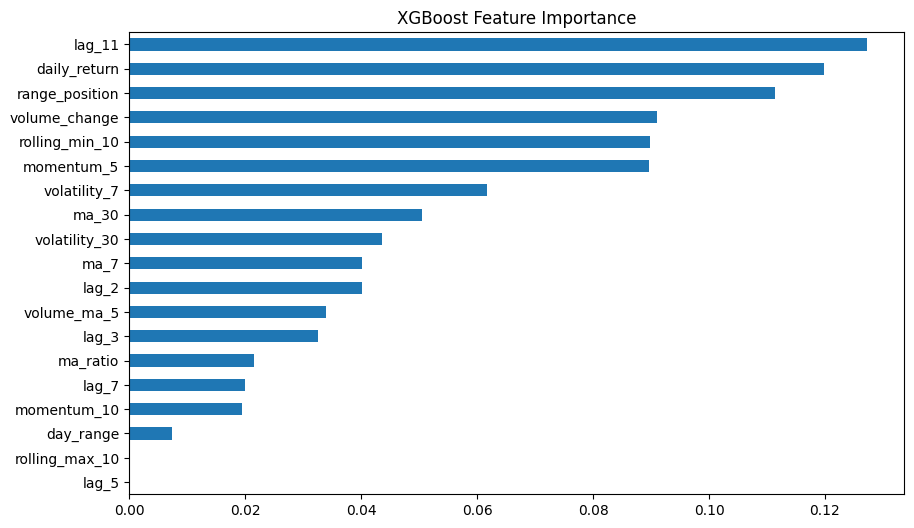

In [136]:
importance = pd.Series(xgb_model.feature_importances_, index=features)

importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()

### **Time Series Cross Validation**

TimeSeriesSplit is used to evaluate model stability across multiple time windows while preserving chronological order.

In [137]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

print("Cross Validation MAE Scores:")
print(-scores)

print("Average MAE:", -scores.mean())

Cross Validation MAE Scores:
[0.00359527 0.00407498 0.00368541 0.00321148 0.00283018]
Average MAE: 0.003479462212289871


## **Classification Target**

Instead of predicting the exact next-day return, the problem is transformed into a binary classification task.

Target definition:
- 1 → Stock price goes UP tomorrow
- 0 → Stock price goes DOWN or remains unchanged

This simplifies the prediction problem and aligns more closely with practical trading decisions.

In [138]:
# create direction target
data['direction'] = (data['next_day_return'] > 0).astype(int)

# check distribution
data['direction'].value_counts()

direction
0    20391
1     1729
Name: count, dtype: int64

### **Handling Class Imbalance**

The NSE dataset contains many days where stock prices remain unchanged, resulting in zero returns.

These zero-return observations create severe class imbalance and cause classification models to predict only the majority class.

To improve learning quality, zero-return observations are removed so the model focuses only on meaningful upward and downward movements.

In [172]:
# remove zero-return rows
classification_data = data[data['next_day_return'] != 0].copy()

print(classification_data.shape)

# recreate direction target
classification_data['direction'] = (
    classification_data['next_day_return'] > 0
).astype(int)

classification_data['direction'].value_counts(normalize=True)

(3367, 21)


direction
1    0.513514
0    0.486486
Name: proportion, dtype: float64

In [173]:
n = len(classification_data)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train = classification_data.iloc[:train_size]
val = classification_data[train_size:train_size + val_size]
test = classification_data[train_size + val_size:]

X_train = train[features]
X_val = val[features]

y_train_class = train['direction']
y_val_class = val['direction']

## **Logistic Regression Classifier**

Logistic Regression is used as the baseline classification model.

The model predicts the probability that the stock price will increase the following day.

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_class)

# predictions
y_pred_class = log_model.predict(X_val_scaled)

In [175]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_val_class, y_pred_class)
precision = precision_score(y_val_class, y_pred_class)
recall = recall_score(y_val_class, y_pred_class)
f1 = f1_score(y_val_class, y_pred_class)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6099009900990099
Precision: 0.5490196078431373
Recall: 0.7400881057268722
F1 Score: 0.6303939962476548


In [176]:
print(classification_report(y_val_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.70      0.50      0.59       278
           1       0.55      0.74      0.63       227

    accuracy                           0.61       505
   macro avg       0.63      0.62      0.61       505
weighted avg       0.63      0.61      0.61       505



## **Confusion Matrix**

The confusion matrix shows:
- Correct upward predictions
- Correct downward predictions
- False predictions

This helps evaluate whether the model is biased toward one class.

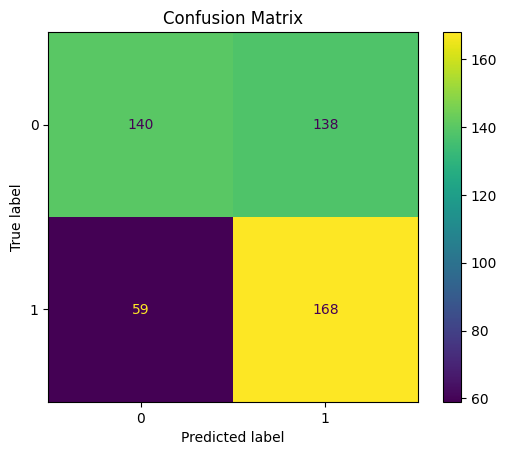

In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val_class, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## **Prediction Probabilities**

The model outputs probabilities representing confidence in upward market movement.

These probabilities can later be used in trading strategy development.

In [178]:
# probability of market going UP
probabilities = log_model.predict_proba(X_val_scaled)[:, 1]

print(probabilities[:10])

[0.50768326 0.37906471 0.52497143 0.44930929 0.6304263  0.49365867
 0.4501273  0.50221196 0.56758401 0.64533544]


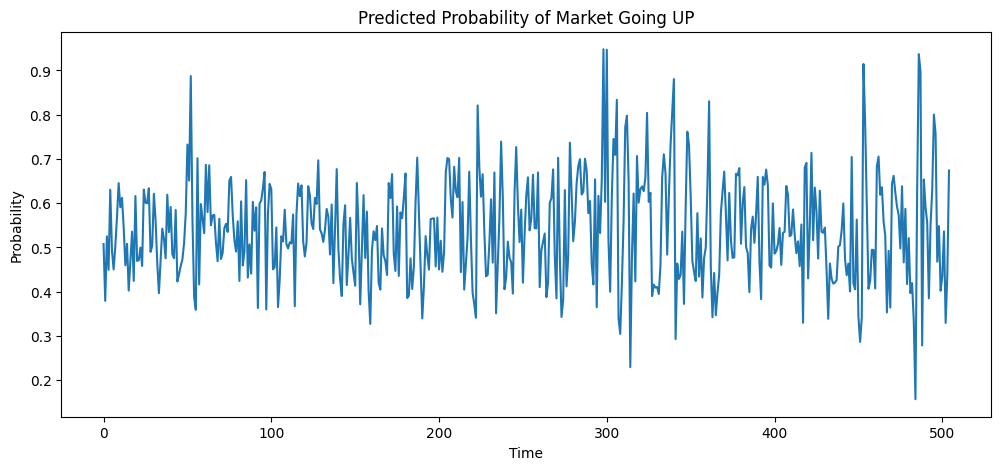

In [179]:
plt.figure(figsize=(12,5))
plt.plot(probabilities)
plt.title("Predicted Probability of Market Going UP")
plt.ylabel("Probability")
plt.xlabel("Time")
plt.show()

### **Logistic Regression Feature Importance**

Feature coefficients indicate the influence of each feature on the probability of upward market movement.

Positive coefficients increase the probability of upward movement, while negative coefficients decrease it.

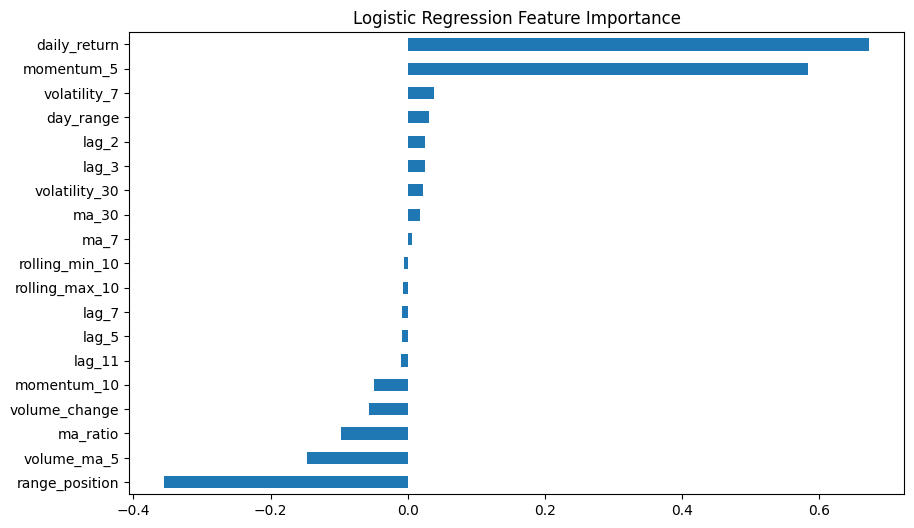

In [180]:
importance = pd.Series(
    log_model.coef_[0],
    index=features
)

importance = importance.sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Logistic Regression Feature Importance")
plt.show()

## **Random Forest Classifier**

A Random Forest classifier is implemented to capture nonlinear relationships and interactions between market indicators.

In [181]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_classifier.fit(X_train, y_train_class)

# predictions
y_pred_rf_class = rf_classifier.predict(X_val)

In [182]:
accuracy_rf = accuracy_score(y_val_class, y_pred_rf_class)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.6415841584158416


In [183]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

xgb_classifier.fit(X_train, y_train_class)

# predictions
y_pred_xgb_class = xgb_classifier.predict(X_val)

In [184]:
accuracy_xgb = accuracy_score(y_val_class, y_pred_xgb_class)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.6475247524752475


### **Classification Model Comparison**

Multiple classification models are compared to determine which approach best predicts market direction.

In [185]:
comparison_class = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest Classifier',
        'XGBoost Classifier'
    ],
    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ]
})

comparison_class

,Model,Accuracy
0,Logistic Regression,0.609901
1,Random Forest Classifier,0.641584
2,XGBoost Classifier,0.647525


## **Classification Model Performance**

After addressing class imbalance by removing zero-return observations, classification performance improved significantly.

### **Results**
- Logistic Regression Accuracy: 60.99%
- Random Forest Accuracy: 64.16%
- XGBoost Accuracy: 64.75%

### **Key Insight**
The classification models outperformed the regression models in predictive usefulness. This suggests that predicting market direction (up or down) is more feasible than predicting exact return values.

Among all models, XGBoost achieved the highest directional accuracy, indicating that nonlinear relationships and feature interactions contribute meaningfully to market direction prediction.

### **Financial Interpretation**
An accuracy above 60% in financial market direction prediction is considered strong due to the inherently noisy and unpredictable nature of stock markets.

# **Selection of Top 20 NSE Stocks**

To expand the analysis beyond a single company, the top 20 NSE stocks were selected based on average trading volume.

High-volume stocks are generally:
- More liquid
- More actively traded
- More representative of overall market behavior

This helps improve model reliability and reduces issues associated with illiquid stocks.

In [188]:
# calculate average trading volume
top_20 = (
    cleaning_df.groupby(['code', 'name'])['volume']
    .mean()
    .round(0)
    .astype(int)
    .sort_values(ascending=False)
    .head(20)
)

top_20

code    name                                    
KCB-R   Kenya Commercial Bank (Rights)              21571350
KPLC-R  Kenya Power and Lighting (Rights)           16997780
SCOM    Safaricom                                   13158574
        Safaricom Plc                                9697032
^N20I   NSE 20-Share Index                           6066206
^NASI   NSE All-Share Index                          5923196
HFCK-R  HFCK-R                                       2479807
EQTY    Equity Group Holdings Plc                    2190759
CFC-R   CFC Stanbic Holdings (Rights)                2000353
KCB     KCB Group Plc                                1826721
KENO    KenolKobil Ltd                               1578701
EQTY    Equity Bank                                  1332872
KCB     Kenya Commercial Bank                        1328062
CIC     CIC Insurance Group                          1304327
KQ-R    Kenya Airways (Rights)                       1180360
MSC     Mumias Sugar                

In [189]:
# get stock codes
top_20_codes = top_20.index.get_level_values('code')

# filter dataset
top20_df = cleaning_df[
    cleaning_df['code'].isin(top_20_codes)
].copy()

print(top20_df.shape)

top20_df[['code', 'name']].drop_duplicates()

(238198, 13)


,code,name
13,EQTY,Equity Bank
15,KCB,Kenya Commercial Bank
30,KEGN,KenGen
31,KENO,KenolKobil
32,KPLC,Kenya Power and Lighting
42,MSC,Mumias Sugar
44,^N20I,NSE 20-Share Index
12147,^NASI,NSE All-Share Index
13897,SCOM,Safaricom
15053,HFCK-R,NaN


## **Feature Engineering Across Multiple Stocks**

Financial indicators were generated separately for each stock using grouped time-series operations.

This ensures:
- Historical calculations remain stock-specific
- Features do not mix information between companies
- Temporal integrity is preserved

In [190]:
# next day return
top20_df['next_day_return'] = (
    top20_df.groupby('code')['day_price']
    .pct_change()
    .shift(-1)
)

# remove zero returns
top20_df = top20_df[
    top20_df['next_day_return'] != 0
].copy()

# classification target
top20_df['direction'] = (
    top20_df['next_day_return'] > 0
).astype(int)